# 📊 Análisis de Tres Estrategias para Productos Estructurados con Capital Protegido
 
> **Horizonte:** 3 meses (S1 & S2) · 6 meses (S3)  
> **Capital del inversor:** $100,000 USD  
> **Tasa libre de riesgo:** 3.62% T-bill 3M (S1/S2) · 3.58% T-bill 6M (S3)

---

## ¿Qué es un producto estructurado con capital protegido?

Un producto estructurado combina dos componentes:

| Componente | Instrumento | Función |
|---|---|---|
| **Protección de capital** | Bono cero cupón (T-bill) | Garantiza devolver el 100% del capital al vencimiento sin importar qué pase en el mercado |
| **Exposición al upside** | Opciones sobre acciones | Permite participar en la ganancia si el mercado se mueve a favor |

La clave es el **presupuesto de opciones**: si el bono cuesta $99,100 de los $100,000 invertidos, quedan exactamente $900 para comprar opciones.

---

## Las tres estrategias analizadas

### Estrategia 1 — Nota Best-Of (AAPL · MSFT · GOOGL)
- **Tesis:** Tendencia alcista en tecnología. El inversor captura el retorno del **mejor activo individual** del trío — basta que uno solo suba.
- **Estructura:** Bull Call Spread sobre el mejor activo + cupón digital del 1.5% si algún activo supera +5%.
- **Protección:** 100% del capital garantizado. **Cap:** 12% máximo.

### Estrategia 2 — Nota Direccional Long-Short (MSFT ↑ / XOM ↓)
- **Tesis:** Divergencia sectorial: Microsoft (tecnología) sube mientras ExxonMobil (energía) baja.
- **Estructura:** Long Call ATM MSFT + Long Put ATM XOM. Ambas patas son opciones compradas → el payoff del derivativo nunca puede ser negativo.
- **Protección:** 100% garantizado. El inversor recibe **siempre** al menos su capital inicial.

### Estrategia 3 — PPN Bull Call Spread sobre Basket (JPM · WMT · MSFT)
PPN (Principal Protected Note)

- **Tesis:** Un basket diversificado de mínima varianza (finanzas + consumo defensivo + tecnología) tendrá un alza moderada a 6 meses.
- **Estructura:** Long Call ATM + Short Call OTM (cap 15%) sobre el basket ponderado. El spread reduce el costo de prima y hace la estructura viable con el presupuesto del ZCB.
- **Protección:** 100% garantizado. **Cap:** 15% máximo.

---

## Metodología paso a paso

```
1. Descarga histórica (yfinance)    → calibrar σ y ρ reales de mercado
2. Optimización Markowitz           → construir basket de mínima varianza
3. Pricing Black-Scholes            → valorar cada opción individualmente
4. Monte Carlo (100,000 escenarios) → valorar el payoff esperado del producto completo
5. Análisis de escenarios           → comunicar el riesgo/retorno al inversor final
```

| Parámetro global | Valor |
|---|---|
| Inversión | $100,000 USD |
| Plazo S1 & S2 | 3 meses |
| Plazo S3 | 6 meses |
| Simulaciones Monte Carlo | 100,000 |
| Semilla aleatoria | 42 (reproducibilidad) |


## 1. Instalación de Dependencias

| Biblioteca | Uso en este notebook |
|---|---|
| `numpy` | Álgebra lineal, vectorización de simulaciones Monte Carlo |
| `pandas` | Series temporales de precios y DataFrames de resultados |
| `matplotlib` | Payoff diagrams, frontera eficiente, histogramas de distribución |
| `seaborn` | Paleta de colores y estilo visual mejorado |
| `yfinance` | Descarga de precios históricos desde Yahoo Finance |
| `scipy` | Optimización convexa (Markowitz), distribución normal (Black-Scholes) |

> `--quiet` suprime los mensajes de `pip` para mantener el output limpio.


In [ ]:
import sys
# Instalación silenciosa de todas las dependencias necesarias
!{sys.executable} -m pip install seaborn yfinance scipy matplotlib numpy pandas --quiet


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip3.12 install --upgrade pip


## 2. Importación de Librerías

Todos los imports en un único bloque para:
1. Facilitar la revisión de dependencias.
2. Configurar el estilo visual global (matplotlib/seaborn) una sola vez para todas las gráficas del notebook.


In [71]:
import numpy as np                        # vectorización y álgebra lineal
import pandas as pd                       # series temporales y DataFrames
import matplotlib.pyplot as plt           # visualizaciones
import matplotlib.patches as mpatches     # leyendas personalizadas
import seaborn as sns                     # estilo visual mejorado
import yfinance as yf                     # datos históricos de mercado
from scipy.optimize import minimize       # optimización cuadrática (Markowitz)
from scipy.stats import norm              # distribución normal (Black-Scholes)
from dataclasses import dataclass         # estructura limpia para opciones
from typing import List, Tuple, Dict      # type hints para legibilidad
import warnings
warnings.filterwarnings('ignore')         # silenciar advertencias menores de yfinance/scipy

# Configuración global de gráficas — aplica a todo el notebook
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 110          # resolución alta para GitHub
plt.rcParams['font.family'] = 'DejaVu Sans'
print("✓ Librerías cargadas")


✓ Librerías cargadas


## 3. Infraestructura Matemática — Black-Scholes, Monte Carlo y Markowitz

Esta sección define las **herramientas de pricing y optimización** compartidas por las tres estrategias.

---

### A. Modelo de Black-Scholes-Merton con dividendos continuos

Para una opción europea sobre un activo que paga dividendos continuos a tasa $q$:

$$C = e^{-rT}\left[F \cdot N(d_1) - K \cdot N(d_2)\right], \quad P = e^{-rT}\left[K \cdot N(-d_2) - F \cdot N(-d_1)\right]$$

Donde $F = S_0 \cdot e^{(r-q)T}$ es el precio forward y:

$$d_1 = \frac{\ln(F/K)}{\sigma\sqrt{T}} + \frac{\sigma\sqrt{T}}{2}, \quad d_2 = d_1 - \sigma\sqrt{T}$$

### B. Simulación Monte Carlo GBM Multivariada

Para $n$ activos correlacionados bajo la medida de riesgo neutro:

$$S_T^{(i)} = S_0^{(i)} \exp\left[(r - \tfrac{\sigma_i^2}{2})T + \sigma_i\sqrt{T}\,Z_i\right]$$

Los shocks correlacionados se construyen con la **descomposición de Cholesky**: $\mathbf{Z} = \mathbf{L}\boldsymbol{\varepsilon}$, donde $\mathbf{L}\mathbf{L}^\top = \boldsymbol{\rho}$ es la matriz de correlación histórica.

### C. Optimización de Markowitz (Media-Varianza)

| Criterio | Función objetivo | Restricciones | Uso en el notebook |
|---|---|---|---|
| **Mínima varianza** | $\min\, \mathbf{w}^\top \Sigma \mathbf{w}$ | $\sum w_i=1$, $w_i\geq0$ | Basket de referencia S1 y S3 |
| **Máximo Sharpe** | $\max\, (\mu_p - r_f)/\sigma_p$ | idem | Comparativa en S1 |

Ambos se resuelven con `scipy.optimize.minimize` método SLSQP (programación cuadrática secuencial).


In [72]:
@dataclass
class OptionElement:
    """Opción europea valorada con Black-Scholes-Merton con dividendos continuos."""
    type: str              # 'call' o 'put'
    strike: float          # precio de ejercicio K
    time_to_expiry: float  # vencimiento en años T
    volatility: float = 0.25   # volatilidad implícita anualizada σ
    int_rate: float   = 0.05   # tasa libre de riesgo continua r
    div_yield: float  = 0.025  # dividend yield continuo q

    def __post_init__(self):
        assert self.type in ['call', 'put']
        self.phi = 1 if self.type == 'call' else -1  # +1 call, -1 put

    def bs_price(self, spot: float, t: float = 0) -> float:
        """Precio Black-Scholes en el instante t (t=0 es hoy, t=T es vencimiento)."""
        tau = self.time_to_expiry - t   # tiempo restante
        if tau <= 0:
            return float(np.maximum(self.phi * (spot - self.strike), 0))  # valor intrínseco al vencimiento
        fwd   = spot * np.exp((self.int_rate - self.div_yield) * tau)  # precio forward
        vol_t = self.volatility * np.sqrt(tau)                          # volatilidad acumulada
        d1    = np.log(fwd / self.strike) / vol_t + 0.5 * vol_t
        d2    = d1 - vol_t
        df    = np.exp(-self.int_rate * tau)                            # factor de descuento
        return self.phi * df * (fwd * norm.cdf(self.phi * d1)
                                - self.strike * norm.cdf(self.phi * d2))

    def delta(self, spot: float) -> float:
        """Delta: sensibilidad del precio de la opción al precio del subyacente."""
        tau   = self.time_to_expiry
        fwd   = spot * np.exp((self.int_rate - self.div_yield) * tau)
        vol_t = self.volatility * np.sqrt(tau)
        d1    = np.log(fwd / self.strike) / vol_t + 0.5 * vol_t
        return self.phi * norm.cdf(self.phi * d1)


def price_option(otype: str, strike: float, spot: float,
                 vol: float, r: float, div: float, T: float) -> float:
    """Interfaz funcional al pricer BS — evita instanciar OptionElement manualmente."""
    return OptionElement(otype, strike, T, vol, r, div).bs_price(spot)


def simulate_gbm(spot: np.ndarray, vols: np.ndarray, corr: np.ndarray,
                 r: float, T: float, n_sims: int, seed: int = 42) -> np.ndarray:
    """Monte Carlo: simula n_sims trayectorias GBM multivariado correlacionado.

    Retorna array (n_sims x n_activos) de precios al tiempo T bajo riesgo neutro.
    La descomposición de Cholesky preserva las correlaciones históricas.
    """
    np.random.seed(seed)                          # semilla fija para reproducibilidad
    L = np.linalg.cholesky(corr)                  # L tal que L @ L.T = corr
    Z = np.random.randn(n_sims, len(spot)) @ L.T  # shocks normales correlacionados
    drift = (r - 0.5 * vols ** 2) * T             # deriva de riesgo neutro
    return spot * np.exp(drift + vols * np.sqrt(T) * Z)


def portfolio_perf(w: np.ndarray, mu: pd.Series,
                   cov: pd.DataFrame) -> Tuple[float, float]:
    """Retorno esperado y volatilidad anualizados de un portafolio con pesos w."""
    return float(np.dot(w, mu)), float(np.sqrt(w @ cov.values @ w))


def optimize_minvar(cov: pd.DataFrame, n: int) -> np.ndarray:
    """Portafolio de mínima varianza: min w'Σw  s.t. sum(w)=1, w≥0 (long-only)."""
    res = minimize(
        lambda w: w @ cov.values @ w,  # varianza del portafolio
        [1/n]*n, method='SLSQP',
        bounds=[(0,1)]*n,              # restricción long-only
        constraints={'type':'eq','fun':lambda w: w.sum()-1}
    )
    return res.x


def optimize_sharpe(mu: pd.Series, cov: pd.DataFrame,
                    rf: float, n: int) -> np.ndarray:
    """Portafolio de máximo Sharpe: max (μp-rf)/σp  s.t. sum(w)=1, w≥0."""
    def neg_sr(w):
        r, s = portfolio_perf(w, mu, cov)
        return -(r - rf) / s  # minimizar el negativo = maximizar el Sharpe
    return minimize(neg_sr, [1/n]*n, method='SLSQP',
                    bounds=[(0,1)]*n,
                    constraints={'type':'eq','fun':lambda w: w.sum()-1}).x

print("✓ Infraestructura BS lista")


✓ Infraestructura BS lista


## 4. Panel de Control — Parámetros Globales

> **Todos los parámetros de las tres estrategias están centralizados aquí.** Para actualizar el análisis, solo hay que editar esta celda y re-ejecutar el notebook completo.

### Cómo actualizar los datos de mercado

| Parámetro | Fuente de actualización |
|---|---|
| `RISK_FREE / S3_RISK_FREE` | FRED — T-Bill secundario (`fred.stlouisfed.org`) |
| `END_DATE` | Actualizar a la fecha de estructuración del producto |
| `S2_..._IV` | Cadena de opciones del broker (IBKR, Bloomberg, Refinitiv) |
| `S2_..._BID / ASK` | Precio bid/ask del contrato en el mercado |
| `S3_CAP` | Ajustar según cuánto upside se quiere ofrecer |

**Lógica de fallback para S2:** Si `IV`, `BID`, `ASK` o `STRIKE` se ponen en `None`, el script calcula automáticamente el valor usando Black-Scholes o el spot actual (ATM).


In [73]:
# ══════════════════════════════════════════════════════════════════════════════
# ══  PARÁMETROS GLOBALES — EDITAR AQUÍ PARA MODIFICAR CUALQUIER ESTRATEGIA  ══
# ══════════════════════════════════════════════════════════════════════════════

# ── Ventana histórica para calibrar σ y ρ ───────────────────────────────────
START_DATE = '2025-01-01'
END_DATE   = '2026-04-18'

# ── Capital y simulación ────────────────────────────────────────────────────
NOTIONAL = 100_000    # capital del inversor en USD
N_SIMS   = 100_000    # trayectorias Monte Carlo (más = más preciso, más lento)
SEED     = 42         # semilla fija para reproducibilidad

# ── Tasas libres de riesgo (fuente: FRED Treasury Bills) ───────────────────
RISK_FREE    = 0.0362  # T-bill 3M USD → usada en S1 y S2
S3_RISK_FREE = 0.0358  # T-bill 6M USD → usada en S3 (plazo mayor)

# ── Plazos en fracción de año ───────────────────────────────────────────────
T    = 3 / 12  # 3 meses (S1 y S2)
S3_T = 6 / 12  # 6 meses (S3)

# ── Universo de acciones ────────────────────────────────────────────────────
TICKERS_S1  = ['AAPL', 'MSFT', 'GOOGL']   # tecnología — Nota Best-Of
TICKERS_S2  = ['MSFT', 'XOM']             # tech vs energía — Nota Direccional
TICKERS_S3  = ['JPM', 'WMT', 'MSFT']     # diversificado — PPN basket
# Unión sin duplicados para hacer una sola llamada a yfinance
ALL_TICKERS = list(dict.fromkeys(TICKERS_S1 + TICKERS_S2 + TICKERS_S3))

# ── Estrategia 1 · Nota Best-Of ─────────────────────────────────────────────
# Payoff = N × (1 + clip(best_of_return × part, 0, cap) + digital)
S1_PARTICIPATION = 1.00   # participación del 100% sobre el mejor activo
S1_CAP           = 0.12   # cap del 12% — máximo retorno del bull call spread
S1_COUPON        = 0.015  # pago digital del 1.5% si algún activo cruza la barrera
S1_BARRIER       = 1.05   # nivel de barrera = precio inicial × 1.05 (+5%)

# ── Estrategia 2 · Long Call MSFT / Long Put XOM ────────────────────────────
# None → el script calcula automáticamente (ATM / precio BS / vol histórica)
S2_PARTICIPATION      = 1.00      # participación fija al 100%

S2_MSFT_CALL_STRIKE   = 425       # strike call MSFT (ligeramente OTM)
S2_MSFT_CALL_MATURITY = T         # vencimiento 3 meses
S2_MSFT_CALL_BID      = 26.00     # bid de mercado (cadena de opciones del broker)
S2_MSFT_CALL_ASK      = 26.50     # ask de mercado — costo real al comprar
S2_MSFT_CALL_IV       = 0.29      # volatilidad implícita del call (29%)
S2_MSFT_DIV_YIELD     = 0.008     # dividend yield continuo de MSFT (~0.8%)

S2_XOM_PUT_STRIKE     = 145       # strike put XOM (ligeramente OTM)
S2_XOM_PUT_MATURITY   = T         # vencimiento 3 meses
S2_XOM_PUT_BID        = 7.40      # bid de mercado
S2_XOM_PUT_ASK        = 7.65      # ask de mercado — costo real al comprar
S2_XOM_PUT_IV         = 0.290867  # volatilidad implícita del put (~29%)
S2_XOM_DIV_YIELD      = 0.035     # dividend yield continuo de XOM (~3.5%)

# ── Estrategia 3 · PPN Bull Call Spread (Basket JPM · WMT · MSFT) ───────────
S3_CAP           = 0.15   # cap del 15% — máximo retorno del basket
S3_PARTICIPATION = 0.60   # 60% de participación — ajustada al presupuesto del ZCB
S3_DIV = {'JPM': 0.025, 'WMT': 0.010, 'MSFT': 0.008}  # yields continuos por ticker

# ── Escenarios para tablas deterministas ────────────────────────────────────
SCENARIO_RANGE = np.array([-0.20, -0.15, -0.10, -0.05,
                             0.00,  0.05,  0.10,  0.15, 0.20])

print("✓ Parámetros globales listos")
print(f"  Tickers únicos : {ALL_TICKERS}")
print(f"  Plazo S1/S2    : {T*12:.0f} meses  |  Tasa: {RISK_FREE*100:.2f}%")
print(f"  Plazo S3       : {S3_T*12:.0f} meses  |  Tasa: {S3_RISK_FREE*100:.2f}%")


✓ Parámetros globales listos
  Tickers únicos : ['AAPL', 'MSFT', 'GOOGL', 'XOM', 'JPM', 'WMT']
  Plazo S1/S2    : 3 meses  |  Tasa: 3.62%
  Plazo S3       : 6 meses  |  Tasa: 3.58%


## Parámetros de Opciones — Estrategia 2 (Guía de actualización)

Los valores se configuran en la **celda de Parámetros Globales** anterior. Esta sección documenta la lógica:

```
STRIKE = None  →  se usa el spot actual (opción exactamente ATM)
BID/ASK = None →  se usa el precio teórico de Black-Scholes como costo
IV = None      →  se usa la volatilidad histórica anualizada del período
```

### Cómo leer la cadena de opciones

Para actualizar con datos reales: abrir la cadena de opciones en el broker → elegir el vencimiento deseado → leer **Strike**, **Bid**, **Ask** e **IV** → actualizar los parámetros `S2_...` en la celda global.

> Usar siempre el `ASK` como costo de compra (precio al que el banco adquiere la opción) y la `IV` de mercado en lugar de la histórica cuando esté disponible.


In [ ]:
# Los parámetros S2 ya están cargados desde la celda de Parámetros Globales.
# Esta celda es un marcador de confirmación en la secuencia de ejecución.
print("✓ Parámetros S2 cargados desde celda global")

✓ Parámetros S2 cargados desde celda global


## 5. Descarga y Preparación de Datos Históricos

Se descarga un único bloque de datos para todo el universo de tickers consolidado, evitando múltiples llamadas a la API.

### Variables calculadas

| Variable | Descripción | Cómo se usa |
|---|---|---|
| `prices_all` | Precios de cierre ajustados (dividendos y splits) | Base para retornos y spots |
| `returns_all` | Retornos diarios simples $r_t = P_t/P_{t-1}-1$ | Calibrar σ y ρ |
| `spots` | Último precio disponible — spot $S_0$ para el pricing | Strikes ATM, simulaciones MC |
| `vols_all` | Volatilidad histórica anualizada $\hat{\sigma} = \text{std}(r) \times \sqrt{252}$ | Fallback cuando no hay IV de mercado |

> **Volatilidad histórica vs. implícita:** La vol histórica tiende a subestimar la IV porque no incluye el *risk premium* de volatilidad. Para S2 se usan las IVs reales de la cadena de opciones del broker.


In [ ]:
print(f"Descargando {ALL_TICKERS}  {START_DATE} → {END_DATE} ...")

# Una sola llamada a yfinance para todo el universo — más eficiente que llamadas individuales
raw = yf.download(ALL_TICKERS, start=START_DATE, end=END_DATE,
                  progress=False, auto_adjust=True)

# Extraer columna 'Close' del MultiIndex que genera yfinance para múltiples tickers
prices_all = raw['Close'] if isinstance(raw.columns, pd.MultiIndex) else raw
prices_all = prices_all[ALL_TICKERS].dropna()  # eliminar filas con NaN (feriados parciales)

# Retornos diarios simples para calibrar covarianzas y volatilidades
returns_all = prices_all.pct_change().dropna()

# Spot actual = último precio (S0 para el pricing de opciones)
spots    = prices_all.iloc[-1]

# Volatilidad histórica anualizada: desviación estándar diaria × √252 días bursátiles
vols_all = returns_all.std() * np.sqrt(252)

print(f"\n✓ {len(returns_all)} días de datos | último: {prices_all.index[-1].date()}")
print("\n📊 Spots y volatilidades anualizadas:")
for t in ALL_TICKERS:
    print(f"  {t:6s}  spot=${spots[t]:>9.2f}  vol={vols_all[t]*100:.1f}%")

Descargando ['AAPL', 'MSFT', 'GOOGL', 'XOM', 'JPM', 'WMT']  2025-01-01 → 2026-04-18 ...

✓ 322 días de datos | último: 2026-04-17

📊 Spots y volatilidades anualizadas:
  AAPL    spot=$   270.23  vol=30.9%
  MSFT    spot=$   422.79  vol=26.6%
  GOOGL   spot=$   341.68  vol=31.3%
  XOM     spot=$   146.44  vol=25.2%
  JPM     spot=$   310.29  vol=25.0%
  WMT     spot=$   127.50  vol=25.4%


## 6. Evolución Histórica de Precios (Base 100)

Para comparar activos con precios nominales muy distintos (AAPL ~$200 vs. XOM ~$100), se normalizan todos los precios a **base 100** al inicio del período.

- Precio normalizado **> 100** → el activo ha subido respecto al inicio.
- Precio normalizado **< 100** → el activo ha caído respecto al inicio.

### Lectura estratégica

Antes de estructurar cualquier producto, es fundamental verificar si la tesis de inversión se habría materializado históricamente en el período de calibración:

- **S1 (AAPL/MSFT/GOOGL):** ¿Han subido? ¿Cuál ha sido el mejor activo del trío (el que habría activado la opción best-of)?
- **S2 (MSFT/XOM):** ¿Ha habido divergencia sectorial tech vs. energía? ¿Se verifica la tesis long-short?
- **S3 (JPM/WMT/MSFT):** ¿Ha tenido el basket un alza moderada y estable, sin caídas severas?


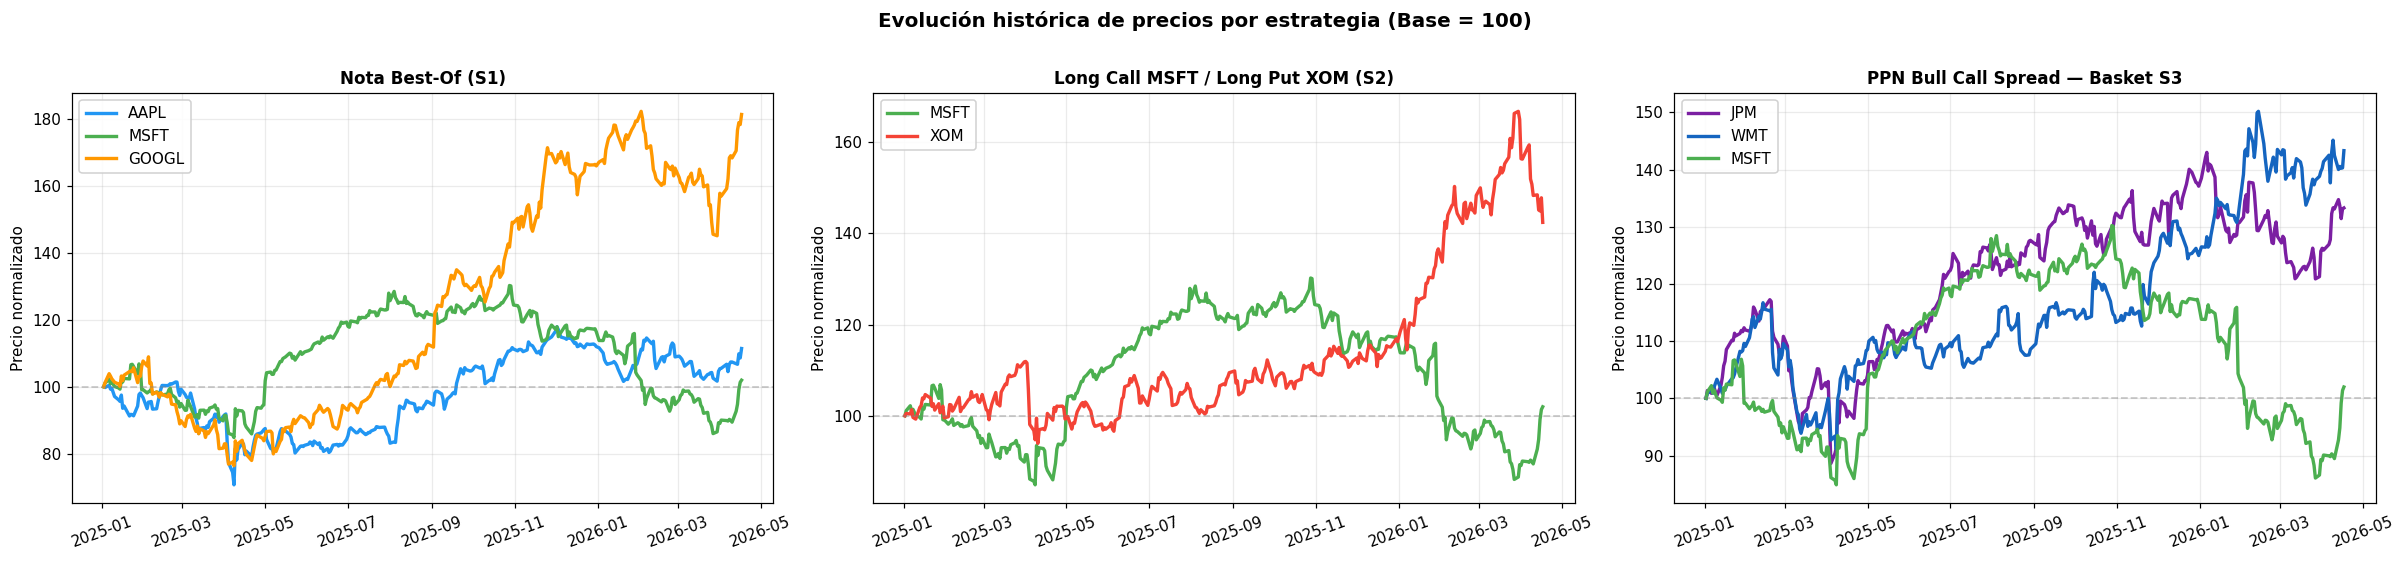


📈 Retornos anualizados:
       Retorno anualizado
Ticker                   
AAPL               +13.2%
MSFT                +5.1%
GOOGL              +51.4%
XOM                +30.9%
JPM                +25.6%
WMT                +31.4%


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

# Grupos de activos con sus colores por estrategia
groups = [
    ('Nota Best-Of (S1)',                 TICKERS_S1, ['#2196F3', '#4CAF50', '#FF9800']),
    ('Long Call MSFT / Long Put XOM (S2)', TICKERS_S2, ['#4CAF50', '#F44336']),
    ('PPN Bull Call Spread — Basket S3',  TICKERS_S3, ['#7B1FA2', '#1565C0', '#4CAF50']),
]

for ax, (title, tickers, colors) in zip(axes, groups):
    # Normalizar a base 100: dividir cada serie por su primer precio disponible
    norm_p = prices_all[tickers] / prices_all[tickers].iloc[0] * 100
    for t, c in zip(tickers, colors):
        ax.plot(norm_p.index, norm_p[t], lw=2.2, color=c, label=t)
    ax.axhline(100, color='gray', ls='--', alpha=0.4, lw=1.2)  # referencia = precio inicial
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel('Precio normalizado')
    ax.legend(framealpha=0.9)
    ax.grid(True, alpha=0.25)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Evolución histórica de precios por estrategia (Base = 100)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Retornos anualizados de referencia para cada activo
print("\n📈 Retornos anualizados:")
ret_anual = returns_all.mean() * 252
print(ret_anual.to_frame('Retorno anualizado').map(lambda x: f'{x*100:+.1f}%'))

---
# 🟦 ESTRATEGIA 1 · Nota Best-Of (AAPL · MSFT · GOOGL)

## Concepto y motivación

La **Nota Best-Of** aumenta la probabilidad de capturar ganancia respecto a una nota estándar: en lugar de necesitar que *todas* las acciones suban, el inversor solo necesita que **una sola** lo haga. Recibe el retorno del activo con mejor rendimiento del grupo.

### Estructura detallada

| Pata | Instrumento | Función |
|---|---|---|
| **Base** | Bono cero cupón 3M | Garantiza devolver $100,000 al vencimiento |
| **Pata 1** | Long Call ATM sobre el best-of | Captura el upside del mejor activo del trío |
| **Pata 2** | Short Call OTM (cap 12%) | Vende el upside extremo para financiar la prima — limita la ganancia al 12% |
| **Pata 3** | Opción digital (barrera +5%) | Paga un cupón adicional del 1.5% si algún activo cruza el +5% |

### Fórmula del payoff

$$\text{Payoff} = N \times \left(1 + \underbrace{\min\big(\max(R_{best}, 0),\, 12\%\big)}_{\text{Bull Call Spread}} + \underbrace{1.5\% \cdot \mathbf{1}\big[\exists\,i: R_i \geq 5\%\big]}_{\text{Cupón digital}}\right)$$

Donde $R_{best} = \max_i\left(S_T^{(i)}/S_0^{(i)} - 1\right)$ es el retorno del mejor activo al vencimiento.

## S1-A. Portafolio de Mínima Varianza

Para contextualizar la nota, se construye el portafolio óptimo de Markowitz. Se elige el **portafolio de mínima varianza** como referencia para el basket: dado que la nota ya captura el upside mediante opciones y elimina el riesgo a la baja mediante el bono, el objetivo del basket es minimizar la volatilidad del subyacente (lo que reduce el costo de las opciones).


In [77]:
# Covarianza y retornos esperados anualizados para los tres activos de S1
ret1 = returns_all[TICKERS_S1]
cov1 = ret1.cov() * 252   # covarianza diaria × 252 = covarianza anualizada
mu1  = ret1.mean() * 252  # retorno esperado anualizado
n1   = len(TICKERS_S1)

# Calcular ambos portafolios óptimos para comparar
w_sharpe = optimize_sharpe(mu1, cov1, RISK_FREE, n1)
w_minvar = optimize_minvar(cov1, n1)

for w, name in [(w_sharpe, 'MÁXIMO SHARPE'), (w_minvar, 'MÍNIMA VARIANZA ✅')]:
    r, s = portfolio_perf(w, mu1, cov1)
    print(f"\n{'='*50}\n{name}\n{'='*50}")
    for t, wi in zip(TICKERS_S1, w):
        print(f"  {t}: {wi*100:.2f}%")
    print(f"  Retorno: {r*100:.2f}%  |  Vol: {s*100:.2f}%  |  Sharpe: {(r-RISK_FREE)/s:.3f}")

# Se elige mínima varianza como portafolio de referencia de la nota
weights_s1 = w_minvar
ret_s1, std_s1 = portfolio_perf(weights_s1, mu1, cov1)
sharpe_s1 = (ret_s1 - RISK_FREE) / std_s1



MÁXIMO SHARPE
  AAPL: 0.00%
  MSFT: 0.00%
  GOOGL: 100.00%
  Retorno: 51.42%  |  Vol: 31.27%  |  Sharpe: 1.528

MÍNIMA VARIANZA ✅
  AAPL: 24.84%
  MSFT: 50.40%
  GOOGL: 24.76%
  Retorno: 18.55%  |  Vol: 22.62%  |  Sharpe: 0.660


## S1-B. Frontera Eficiente de Markowitz

La **frontera eficiente** es el conjunto de portafolios que ofrecen el máximo retorno esperado para cada nivel de volatilidad. Todo portafolio por debajo de la frontera es subóptimo.

### Construcción

1. **8,000 portafolios aleatorios** (pesos Dirichlet, long-only) → muestran el espacio factible de combinaciones.
2. **Frontera exacta** resolviendo 100 problemas de mínima varianza con retorno objetivo creciente.
3. **Dos portafolios especiales:**
   - ⭐ Rojo: **Máximo Sharpe** — punto de tangencia con la línea de mercado de capitales (CML).
   - ⭐ Dorado: **Mínima Varianza ✅** — extremo izquierdo de la frontera, elegido para la nota.

El color de cada punto de la nube codifica su **Sharpe ratio** (amarillo = alto, azul/morado = bajo), permitiendo visualizar la "zona óptima" del espacio de portafolios.


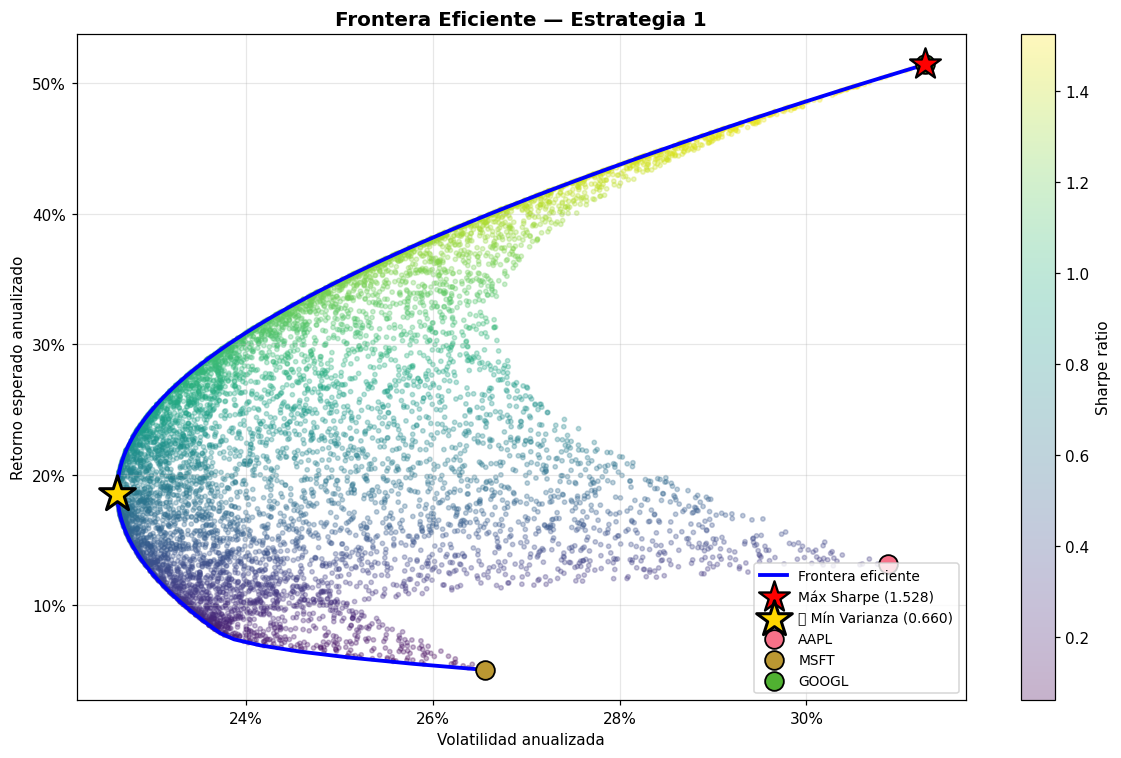

In [78]:
def efficient_frontier(mu, cov, n_pts=100):
    """Construye la frontera eficiente resolviendo n_pts problemas de mínima
    varianza con retorno objetivo fijo y creciente."""
    n = len(mu)
    tgts = np.linspace(mu.min(), mu.max(), n_pts)  # retornos objetivo espaciados uniformemente
    vols = []
    for tgt in tgts:
        r = minimize(lambda w: w @ cov.values @ w, [1/n]*n, method='SLSQP',
                     bounds=[(0, 1)]*n,
                     constraints=[
                         {'type': 'eq', 'fun': lambda w: w.sum() - 1},
                         {'type': 'eq', 'fun': lambda w, t=tgt: mu @ w - t}  # retorno fijo = tgt
                     ])
        vols.append(np.sqrt(r.fun) if r.success else np.nan)
    return tgts, np.array(vols)

ef_ret, ef_vol = efficient_frontier(mu1, cov1)

# 8,000 portafolios aleatorios long-only para mostrar el espacio factible
np.random.seed(SEED)
rw = np.random.dirichlet(np.ones(n1), 8000)
rr = rw @ mu1.values
rs = np.sqrt(np.einsum('ij,jk,ik->i', rw, cov1.values, rw))  # volatilidades vectorizadas

r_mv, s_mv = portfolio_perf(w_minvar, mu1, cov1)
r_sr, s_sr = portfolio_perf(w_sharpe, mu1, cov1)

fig, ax = plt.subplots(figsize=(11, 7))
# Nube de portafolios coloreados por Sharpe ratio
sc = ax.scatter(rs, rr, c=(rr - RISK_FREE) / rs, cmap='viridis', alpha=0.3, s=8)
plt.colorbar(sc, label='Sharpe ratio')
ax.plot(ef_vol, ef_ret, 'b-', lw=2.5, label='Frontera eficiente')
ax.scatter(s_sr, r_sr, marker='*', s=450, c='red',  edgecolors='k', lw=1.5, zorder=5,
           label=f"Máx Sharpe ({(r_sr-RISK_FREE)/s_sr:.3f})")
ax.scatter(s_mv, r_mv, marker='*', s=600, c='gold', edgecolors='k', lw=2,   zorder=6,
           label=f"✅ Mín Varianza ({(r_mv-RISK_FREE)/s_mv:.3f})")
for i, t in enumerate(TICKERS_S1):
    ax.scatter(np.sqrt(cov1.iloc[i,i]), mu1.iloc[i], marker='o', s=150,
               edgecolors='k', lw=1.2, label=t, zorder=4)
ax.set_xlabel('Volatilidad anualizada')
ax.set_ylabel('Retorno esperado anualizado')
ax.set_title('Frontera Eficiente — Estrategia 1', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
plt.tight_layout()
plt.show()


## S1-C. Pricing Monte Carlo — Nota Best-Of

### ¿Por qué Monte Carlo y no una fórmula cerrada?

La Nota Best-Of tiene un payoff que depende del **máximo de varios activos correlacionados**. No existe una fórmula cerrada de Black-Scholes para este tipo de producto. La simulación numérica es el método estándar de la industria.

### Proceso del pricing

1. Simular $N = 100{,}000$ vectores de precios finales bajo la **medida de riesgo neutro** (drift = tasa libre de riesgo $r$, no la media histórica).
2. Calcular el payoff contractual para cada simulación.
3. Descontar el promedio: $\text{Fair Value} = e^{-rT} \cdot \mathbb{E}[\text{Payoff}]$

### ¿Por qué la medida de riesgo neutro?

Bajo la medida de riesgo neutro todos los activos crecen a la tasa libre de riesgo $r$. Esto garantiza que el fair value calculado sea el **precio de no-arbitraje** del producto, independientemente de las preferencias de riesgo del inversor o las tendencias históricas de los activos.

### Interpretación del "margen del banco"

$\text{Notional} - \text{Fair Value}$ = margen implícito que el banco captura al vender la nota a la par. Cubre el costo de la garantía, la distribución y el beneficio del emisor.


In [79]:
# Spots, volatilidades y correlaciones históricas para S1
spots1 = np.array([spots[t] for t in TICKERS_S1])
vols1  = np.array([vols_all[t] for t in TICKERS_S1])
corr1  = returns_all[TICKERS_S1].corr().values  # matriz de correlación histórica


def note_payoff(finals, spot, notional, part, cap, coupon, barrier):
    """Payoff de la Nota Best-Of con Bull Call Spread y cupón digital.

    Argumentos:
        finals  : array (n_sims × n_activos) de precios simulados al vencimiento
        spot    : array (n_activos,) de precios iniciales S0
        notional: capital del inversor
        part    : tasa de participación (1.0 = 100%)
        cap     : máximo retorno del bull call spread (0.12 = 12%)
        coupon  : pago del cupón digital (0.015 = 1.5%)
        barrier : nivel que activa el cupón digital (1.05 = +5%)

    Retorna:
        payoff total, componente best-of, componente digital
    """
    ret     = finals / spot - 1                          # retornos al vencimiento
    best    = ret.max(axis=1)                            # mejor retorno del trío
    best_of = np.clip(part * best, 0, cap)               # acotado entre 0% y cap (spread)
    digital = np.any(finals / spot >= barrier, axis=1).astype(float) * coupon
    return notional * (1 + best_of + digital), best_of, digital


# Simular N_SIMS trayectorias bajo medida de riesgo neutro
finals1 = simulate_gbm(spots1, vols1, corr1, RISK_FREE, T, N_SIMS, SEED)
payoff1, bo1, dig1 = note_payoff(finals1, spots1, NOTIONAL,
                                  S1_PARTICIPATION, S1_CAP, S1_COUPON, S1_BARRIER)

# Descomposición del capital del inversor
pv_bond1       = NOTIONAL * np.exp(-RISK_FREE * T)    # valor presente del bono (protección capital)
option_budget1 = NOTIONAL - pv_bond1                  # presupuesto para opciones
fair_value1    = np.exp(-RISK_FREE * T) * payoff1.mean()  # VP del payoff esperado = precio justo
exp_ret1       = payoff1.mean() / NOTIONAL - 1        # retorno esperado sobre el capital

print("=" * 60)
print("  PRICING NOTA BEST-OF (Monte Carlo)")
print("=" * 60)
print(f"  Fair value:                    ${fair_value1:>12,.2f}")
print(f"  Margen banco (nota vendida @par): ${NOTIONAL - fair_value1:>9,.2f}")
print(f"  Retorno esperado (3m):         {exp_ret1*100:>+8.2f}%  →  {exp_ret1/T*100:+.2f}% anual")
print(f"  VP bono (protección capital):  ${pv_bond1:>12,.2f}")
print(f"  Presupuesto opciones:          ${option_budget1:>12,.2f}")
print(f"  Prob. ganancia (> capital):    {(payoff1 > NOTIONAL).mean()*100:>8.1f}%")
print(f"  Prob. alcanzar cap ({S1_CAP*100:.0f}%):    {(bo1 >= S1_CAP-1e-6).mean()*100:>8.1f}%")
print(f"  Prob. cobrar cupón digital:    {(dig1 > 0).mean()*100:>8.1f}%")
print(f"  Payoff promedio:               ${payoff1.mean():>12,.2f}")
print(f"  Payoff percentil 5%:           ${np.percentile(payoff1, 5):>12,.2f}")
print(f"  Payoff percentil 95%:          ${np.percentile(payoff1, 95):>12,.2f}")


  PRICING NOTA BEST-OF (Monte Carlo)
  Fair value:                    $  107,232.58
  Margen banco (nota vendida @par): $-7,232.58
  Retorno esperado (3m):            +8.21%  →  +32.83% anual
  VP bono (protección capital):  $   99,099.08
  Presupuesto opciones:          $      900.92
  Prob. ganancia (> capital):        76.9%
  Prob. alcanzar cap (12%):        43.4%
  Prob. cobrar cupón digital:        63.5%
  Payoff promedio:               $  108,207.44
  Payoff percentil 5%:           $  100,000.00
  Payoff percentil 95%:          $  113,500.00


## S1-D. Diagrama de Payoff y Distribución de Resultados

Tres paneles que muestran la anatomía completa de la Nota Best-Of:

### Panel 1 — Descomposición por componentes
Muestra cómo se acumulan los tres componentes del payoff en función del retorno del mejor activo:
- **Azul:** Bono cero cupón — garantiza el capital en todo momento.
- **Verde:** Bull Call Spread — gana linealmente cuando el mejor activo sube, acotado al cap del 12%.
- **Naranja:** Cupón digital — bonus del 1.5% que se activa al cruzar la barrera del +5%.

### Panel 2 — Distribución Monte Carlo
Compara la distribución de los 100,000 payoffs de la nota vs. una inversión directa en el portafolio min-var (sin protección, sin cap). La nota tiene distribución **asimétrica positiva**: la cola izquierda está truncada en $100,000 mientras la cola derecha llega al cap.

### Panel 3 — Nota vs. Inversión Directa
- **Verde:** Zona donde la nota supera a la inversión directa (mercados bajistas → protección activa).
- **Rojo:** Pérdida que se habría sufrido sin protección (ahora evitada).
- **Azul oscuro:** Costo de oportunidad (mercados muy alcistas que superan el cap → la inversión directa habría ganado más).


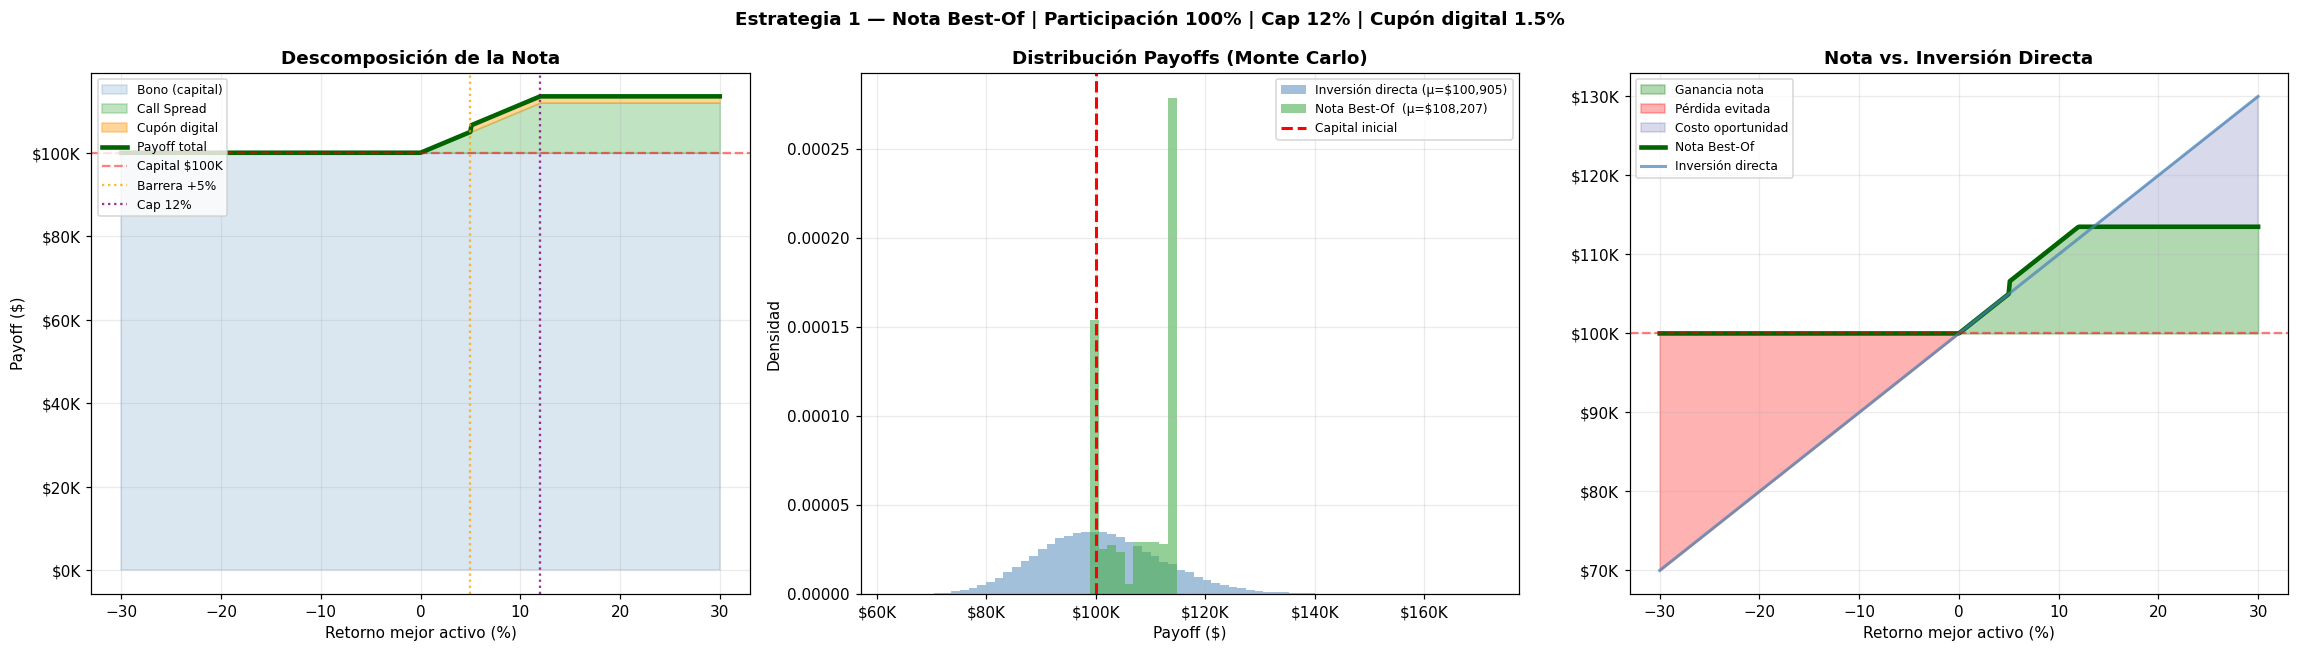

In [80]:
br = np.linspace(-0.30, 0.30, 500)
bond_pf   = np.full_like(br, NOTIONAL)
cs_pf     = np.where(br <= 0, 0, np.minimum(S1_PARTICIPATION * br, S1_CAP) * NOTIONAL)
dig_pf    = np.where(br >= S1_BARRIER - 1, S1_COUPON * NOTIONAL, 0)
total_pf  = bond_pf + cs_pf + dig_pf
direct_pf = NOTIONAL * (1 + br)

ret_sim1   = finals1 / spots1 - 1
direct_mc1 = NOTIONAL * (1 + ret_sim1 @ weights_s1)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Panel 1: Descomposición
ax = axes[0]
ax.fill_between(br*100, 0, bond_pf, alpha=0.20, color='steelblue', label='Bono (capital)')
ax.fill_between(br*100, bond_pf, bond_pf+cs_pf, alpha=0.35, color='#4CAF50', label='Call Spread')
ax.fill_between(br*100, bond_pf+cs_pf, total_pf, alpha=0.40, color='#FF9800', label='Cupón digital')
ax.plot(br*100, total_pf, lw=3, color='darkgreen', label='Payoff total')
ax.axhline(NOTIONAL, color='red', ls='--', alpha=0.5, lw=1.5, label=f'Capital ${NOTIONAL/1000:.0f}K')
ax.axvline((S1_BARRIER-1)*100, color='orange', ls=':', alpha=0.8,
           label=f'Barrera +{(S1_BARRIER-1)*100:.0f}%')
ax.axvline(S1_CAP*100, color='purple', ls=':', alpha=0.8, label=f'Cap {S1_CAP*100:.0f}%')
ax.set_title('Descomposición de la Nota', fontweight='bold')
ax.set_xlabel('Retorno mejor activo (%)')
ax.set_ylabel('Payoff ($)')
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.25)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Panel 2: Distribución MC
ax = axes[1]
lo, hi = min(direct_mc1.min(), payoff1.min()), max(direct_mc1.max(), payoff1.max())
bins = np.linspace(lo, hi, 70)
ax.hist(direct_mc1, bins=bins, alpha=0.50, color='steelblue', density=True,
        label=f'Inversión directa (μ=${direct_mc1.mean():,.0f})')
ax.hist(payoff1,    bins=bins, alpha=0.60, color='#4CAF50',  density=True,
        label=f'Nota Best-Of  (μ=${payoff1.mean():,.0f})')
ax.axvline(NOTIONAL, color='red', ls='--', lw=2, label='Capital inicial')
ax.set_title('Distribución Payoffs (Monte Carlo)', fontweight='bold')
ax.set_xlabel('Payoff ($)')
ax.set_ylabel('Densidad')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Panel 3: Nota vs. Directa
ax = axes[2]
ax.fill_between(br*100, NOTIONAL, total_pf,
                where=total_pf > NOTIONAL, alpha=0.30, color='green', label='Ganancia nota')
ax.fill_between(br*100, NOTIONAL, direct_pf,
                where=direct_pf < NOTIONAL, alpha=0.30, color='red', label='Pérdida evitada')
ax.fill_between(br*100, total_pf, direct_pf,
                where=direct_pf > total_pf, alpha=0.15, color='navy', label='Costo oportunidad')
ax.plot(br*100, total_pf, lw=3, color='darkgreen', label='Nota Best-Of')
ax.plot(br*100, direct_pf, lw=2, color='steelblue', alpha=0.7, label='Inversión directa')
ax.axhline(NOTIONAL, color='red', ls='--', alpha=0.5)
ax.set_title('Nota vs. Inversión Directa', fontweight='bold')
ax.set_xlabel('Retorno mejor activo (%)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.suptitle(
    f'Estrategia 1 — Nota Best-Of | Participación {S1_PARTICIPATION*100:.0f}% '
    f'| Cap {S1_CAP*100:.0f}% | Cupón digital {S1_COUPON*100:.1f}%',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## S1-E. Tabla de Escenarios Deterministas

Traduce el modelo a **lenguaje de inversor**: para cada escenario hipotético, muestra cuánto cobraría exactamente.

### Tipos de escenarios

1. **Movimiento paralelo (-20% a +20%):** Todos los activos se mueven igual — muestra el rango completo.
2. **Escenarios asimétricos personalizados:** Un activo lidera mientras otros caen — ilustra el valor de la opción "best-of".
3. **Escenario corrección:** Todos caen → Payoff = $100,000 siempre (protección activa).

> **Columna "Best-Of":** retorno del mejor activo acotado al cap.  
> **Columna "Cupón":** indica si se activó el pago digital del 1.5%.  
> **Columna "Payoff":** monto total que recibe el inversor al vencimiento.


In [81]:
# Construir tabla de escenarios: primero movimientos paralelos, luego asimétricos
rows = []
for r in SCENARIO_RANGE:
    f = spots1 * (1 + r)
    po, bo, dg = note_payoff(f.reshape(1, -1), spots1, NOTIONAL,
                              S1_PARTICIPATION, S1_CAP, S1_COUPON, S1_BARRIER)
    rows.append({'Escenario': f'Todos {r*100:+.0f}%',
                 'AAPL': f'{r*100:+.1f}%', 'MSFT': f'{r*100:+.1f}%', 'GOOGL': f'{r*100:+.1f}%',
                 'Best-Of': f'{bo[0]*100:.2f}%', 'Cupón': f'{dg[0]*100:.2f}%',
                 'Payoff': f'${po[0]:,.0f}', 'Rend.': f'{(po[0]/NOTIONAL-1)*100:+.2f}%'})

for r1, r2, r3, desc in [
    (0.15, 0.20, 0.10, "MSFT líder"),
    (0.08, 0.15, 0.20, "GOOGL lidera"),
    (-0.05, 0.15, -0.05, "Solo MSFT sube"),
    (-0.10, 0.15, -0.05, "MSFT salva trimestre"),
    (-0.15, -0.10, -0.12, "Corrección general"),
]:
    f = np.array([spots1[0]*(1+r1), spots1[1]*(1+r2), spots1[2]*(1+r3)])
    po, bo, dg = note_payoff(f.reshape(1, -1), spots1, NOTIONAL,
                              S1_PARTICIPATION, S1_CAP, S1_COUPON, S1_BARRIER)
    rows.append({'Escenario': desc,
                 'AAPL': f'{r1*100:+.1f}%', 'MSFT': f'{r2*100:+.1f}%', 'GOOGL': f'{r3*100:+.1f}%',
                 'Best-Of': f'{bo[0]*100:.2f}%', 'Cupón': f'{dg[0]*100:.2f}%',
                 'Payoff': f'${po[0]:,.0f}', 'Rend.': f'{(po[0]/NOTIONAL-1)*100:+.2f}%'})

df_s1 = pd.DataFrame(rows)
print(df_s1.to_string(index=False))
df_s1

           Escenario   AAPL   MSFT  GOOGL Best-Of Cupón   Payoff   Rend.
          Todos -20% -20.0% -20.0% -20.0%   0.00% 0.00% $100,000  +0.00%
          Todos -15% -15.0% -15.0% -15.0%   0.00% 0.00% $100,000  +0.00%
          Todos -10% -10.0% -10.0% -10.0%   0.00% 0.00% $100,000  +0.00%
           Todos -5%  -5.0%  -5.0%  -5.0%   0.00% 0.00% $100,000  +0.00%
           Todos +0%  +0.0%  +0.0%  +0.0%   0.00% 0.00% $100,000  +0.00%
           Todos +5%  +5.0%  +5.0%  +5.0%   5.00% 1.50% $106,500  +6.50%
          Todos +10% +10.0% +10.0% +10.0%  10.00% 1.50% $111,500 +11.50%
          Todos +15% +15.0% +15.0% +15.0%  12.00% 1.50% $113,500 +13.50%
          Todos +20% +20.0% +20.0% +20.0%  12.00% 1.50% $113,500 +13.50%
          MSFT líder +15.0% +20.0% +10.0%  12.00% 1.50% $113,500 +13.50%
        GOOGL lidera  +8.0% +15.0% +20.0%  12.00% 1.50% $113,500 +13.50%
      Solo MSFT sube  -5.0% +15.0%  -5.0%  12.00% 1.50% $113,500 +13.50%
MSFT salva trimestre -10.0% +15.0%  -5.0%  12.00% 1

,Escenario,AAPL,MSFT,GOOGL,Best-Of,Cupón,Payoff,Rend.
0,Todos -20%,-20.0%,-20.0%,-20.0%,0.00%,0.00%,"$100,000",+0.00%
1,Todos -15%,-15.0%,-15.0%,-15.0%,0.00%,0.00%,"$100,000",+0.00%
2,Todos -10%,-10.0%,-10.0%,-10.0%,0.00%,0.00%,"$100,000",+0.00%
3,Todos -5%,-5.0%,-5.0%,-5.0%,0.00%,0.00%,"$100,000",+0.00%
4,Todos +0%,+0.0%,+0.0%,+0.0%,0.00%,0.00%,"$100,000",+0.00%
5,Todos +5%,+5.0%,+5.0%,+5.0%,5.00%,1.50%,"$106,500",+6.50%
6,Todos +10%,+10.0%,+10.0%,+10.0%,10.00%,1.50%,"$111,500",+11.50%
7,Todos +15%,+15.0%,+15.0%,+15.0%,12.00%,1.50%,"$113,500",+13.50%
8,Todos +20%,+20.0%,+20.0%,+20.0%,12.00%,1.50%,"$113,500",+13.50%
9,MSFT líder,+15.0%,+20.0%,+10.0%,12.00%,1.50%,"$113,500",+13.50%


---
# 🟩 ESTRATEGIA 2 · Nota Direccional Long-Short (MSFT ↑ / XOM ↓)

## Concepto y motivación

Esta estrategia apuesta a una **divergencia sectorial**: Microsoft (tecnología) sube mientras ExxonMobil (energía) baja. Esta dinámica es frecuente en períodos de transición energética, donde los capitales rotan del sector fósil hacia el sector digital.

### Estructura

| Pata | Instrumento | Función |
|---|---|---|
| **Base** | Bono cero cupón 3M | Garantiza devolver $100,000 al vencimiento |
| **Pata 1** | Long Call ATM sobre MSFT | Gana si MSFT supera el strike al vencimiento |
| **Pata 2** | Long Put ATM sobre XOM | Gana si XOM cae por debajo del strike al vencimiento |

### Garantía matemática de no pérdida

Ambas patas son **opciones compradas** (*long options*): su valor intrínseco es siempre $\geq 0$. Por lo tanto:

$$\text{Payoff derivativo} = N \times \max\left(0,\, \frac{\max(S_T^{MSFT} - K,0)}{S_0^{MSFT}} + \frac{\max(K - S_T^{XOM},0)}{S_0^{XOM}}\right) \geq 0$$

$$\Rightarrow \text{Payoff Total} = N + \text{Payoff derivativo} \geq N \quad \text{en todos los escenarios}$$

### Análisis de escenarios clave

| Escenario | MSFT | XOM | Resultado para el inversor |
|---|---|---|---|
| **Tesis correcta** | ↑ | ↓ | Ambas patas ganan → mayor payoff |
| **Solo MSFT sube** | ↑ | → | Solo la call contribuye → payoff moderado |
| **Solo XOM baja** | → | ↓ | Solo la put contribuye → payoff moderado |
| **Tesis incorrecta** | ↓ | ↑ | Ninguna opción ejerce → Payoff = $100,000 exactamente |

## S2-A. Resolución de parámetros (mercado vs. Black-Scholes)


In [82]:
# Verificación rápida del spot de XOM antes de proceder con la configuración completa
S0_XOM  = float(spots['XOM'])
S0_XOM


146.44000244140625

In [83]:
# ── Spots iniciales (S0) desde el último precio disponible en el dataset ─────
S0_MSFT = float(spots['MSFT'])
S0_XOM  = float(spots['XOM'])

# Volatilidades históricas como fallback (se sobrescriben con IV de mercado si están disponibles)
VOL_MSFT = float(vols_all['MSFT'])
VOL_XOM  = float(vols_all['XOM'])

# ── Strikes: usar los definidos en parámetros globales o ATM automático ──────
K_MSFT = S2_MSFT_CALL_STRIKE if S2_MSFT_CALL_STRIKE is not None else round(S0_MSFT, 2)
K_XOM  = S2_XOM_PUT_STRIKE   if S2_XOM_PUT_STRIKE   is not None else round(S0_XOM, 2)

# ── Volatilidades implícitas: de mercado si existen, históricas si no ────────
IV_MSFT = S2_MSFT_CALL_IV if S2_MSFT_CALL_IV is not None else VOL_MSFT
IV_XOM  = S2_XOM_PUT_IV   if S2_XOM_PUT_IV   is not None else VOL_XOM

# ── Plazos de vencimiento ─────────────────────────────────────────────────────
T_MSFT = S2_MSFT_CALL_MATURITY
T_XOM  = S2_XOM_PUT_MATURITY

# ── Precios teóricos Black-Scholes (referencia para comparar con precios de mercado) ─
bs_price_call_msft = price_option('call', K_MSFT, S0_MSFT, IV_MSFT,
                                   RISK_FREE, S2_MSFT_DIV_YIELD, T_MSFT)
bs_price_put_xom   = price_option('put',  K_XOM,  S0_XOM,  IV_XOM,
                                   RISK_FREE, S2_XOM_DIV_YIELD,  T_XOM)

# ── Precios reales: usar ask de mercado si está disponible, BS teórico si no ─
if S2_MSFT_CALL_BID is not None and S2_MSFT_CALL_ASK is not None:
    market_mid_call   = (S2_MSFT_CALL_BID + S2_MSFT_CALL_ASK) / 2
    cost_call_msft    = S2_MSFT_CALL_ASK   # se paga el ask al comprar
    using_market_msft = True
else:
    market_mid_call   = bs_price_call_msft
    cost_call_msft    = bs_price_call_msft
    using_market_msft = False

if S2_XOM_PUT_BID is not None and S2_XOM_PUT_ASK is not None:
    market_mid_put   = (S2_XOM_PUT_BID + S2_XOM_PUT_ASK) / 2
    cost_put_xom     = S2_XOM_PUT_ASK    # se paga el ask al comprar
    using_market_xom = True
else:
    market_mid_put   = bs_price_put_xom
    cost_put_xom     = bs_price_put_xom
    using_market_xom = False

# ── Presupuesto de opciones (dinero sobrante tras comprar el ZCB) ─────────────
pv_zcb2           = NOTIONAL * np.exp(-RISK_FREE * T)
option_budget2    = NOTIONAL - pv_zcb2
total_option_cost = cost_call_msft + cost_put_xom

print("=" * 70)
print("  ESTRATEGIA 2 — NOTA DIRECCIONAL LONG-SHORT")
print("  Long Call MSFT / Long Put XOM · Capital 100% Protegido")
print("=" * 70)
print(f"\n  MSFT (Alcista — Long Call)")
print(f"    Spot (S0):         ${S0_MSFT:>10.2f}")
print(f"    Strike (K):        ${K_MSFT:>10.2f}  ({'ATM' if abs(K_MSFT/S0_MSFT - 1) < 0.01 else f'{(K_MSFT/S0_MSFT-1)*100:+.1f}% OTM'})")
print(f"    Madurez:           {T_MSFT*12:>10.1f} meses")
print(f"    IV:                {IV_MSFT*100:>10.1f}%  ({'mercado' if S2_MSFT_CALL_IV is not None else 'histórica'})")
if using_market_msft:
    print(f"    Bid / Ask:         ${S2_MSFT_CALL_BID:>8.2f} / ${S2_MSFT_CALL_ASK:>8.2f}")
print(f"    Precio BS teórico: ${bs_price_call_msft:>10.2f}")
print(f"    Costo de compra:   ${cost_call_msft:>10.2f}  ({'ask mercado' if using_market_msft else 'BS teórico'})")
print(f"\n  XOM (Bajista — Long Put)")
print(f"    Spot (S0):         ${S0_XOM:>10.2f}")
print(f"    Strike (K):        ${K_XOM:>10.2f}  ({'ATM' if abs(K_XOM/S0_XOM - 1) < 0.01 else f'{(K_XOM/S0_XOM-1)*100:+.1f}% OTM'})")
print(f"    Madurez:           {T_XOM*12:>10.1f} meses")
print(f"    IV:                {IV_XOM*100:>10.1f}%  ({'mercado' if S2_XOM_PUT_IV is not None else 'histórica'})")
if using_market_xom:
    print(f"    Bid / Ask:         ${S2_XOM_PUT_BID:>8.2f} / ${S2_XOM_PUT_ASK:>8.2f}")
print(f"    Precio BS teórico: ${bs_price_put_xom:>10.2f}")
print(f"    Costo de compra:   ${cost_put_xom:>10.2f}  ({'ask mercado' if using_market_xom else 'BS teórico'})")
print(f"\n  ESTRUCTURA DE CAPITAL")
print(f"    Notional:              ${NOTIONAL:>12,.2f}")
print(f"    VP del ZCB @ {RISK_FREE*100:.2f}%:    ${pv_zcb2:>12,.2f}")
print(f"    Presupuesto opciones:  ${option_budget2:>12,.2f}")
print(f"    Costo total opciones:  ${total_option_cost:>12,.2f}")
print(f"    Participación:         {'100%':>12}  (fija)")
viable = total_option_cost <= option_budget2
print(f"\n  Factibilidad: {'✅ SÍ — costo cabe en presupuesto' if viable else '⚠️ NO — costo excede presupuesto, ajustar strikes OTM'}")


  ESTRATEGIA 2 — NOTA DIRECCIONAL LONG-SHORT
  Long Call MSFT / Long Put XOM · Capital 100% Protegido

  MSFT (Alcista — Long Call)
    Spot (S0):         $    422.79
    Strike (K):        $    425.00  (ATM)
    Madurez:                  3.0 meses
    IV:                      29.0%  (mercado)
    Bid / Ask:         $   26.00 / $   26.50
    Precio BS teórico: $     24.75
    Costo de compra:   $     26.50  (ask mercado)

  XOM (Bajista — Long Put)
    Spot (S0):         $    146.44
    Strike (K):        $    145.00  (ATM)
    Madurez:                  3.0 meses
    IV:                      29.1%  (mercado)
    Bid / Ask:         $    7.40 / $    7.65
    Precio BS teórico: $      7.66
    Costo de compra:   $      7.65  (ask mercado)

  ESTRUCTURA DE CAPITAL
    Notional:              $  100,000.00
    VP del ZCB @ 3.62%:    $   99,099.08
    Presupuesto opciones:  $      900.92
    Costo total opciones:  $       34.15
    Participación:                 100%  (fija)

  Factibilidad: 

## S2-B. Función de Payoff — Derivativo Direccional Long-Short

La función `directional_ls_payoff` implementa la fórmula contractual y está vectorizada para trabajar eficientemente con los 100,000 escenarios Monte Carlo simultáneamente.

### Fórmula detallada

$$\text{Payoff Total} = N + N \times P \times \max\left(0,\, \underbrace{\frac{\max(S_T^{MSFT} - K_{MSFT}, 0)}{S_0^{MSFT}}}_{\text{call MSFT normalizada}} + \underbrace{\frac{\max(K_{XOM} - S_T^{XOM}, 0)}{S_0^{XOM}}}_{\text{put XOM normalizada}}\right)$$

### Normalización por el spot inicial ($S_0$)

Dividir el valor intrínseco de cada opción por su spot inicial ($S_0$) convierte el payoff de dólares absolutos a **porcentaje de retorno**. Esto es necesario porque las dos acciones tienen precios nominales muy distintos (MSFT ~$420 vs. XOM ~$100) y ambas deben contribuir equitativamente al retorno porcentual sobre el capital del inversor.

### Por qué el `max(..., 0)` exterior

La suma de las dos patas siempre es $\geq 0$ (ambas son *long options*), por lo que el `max` exterior es redundante matemáticamente pero útil como salvaguarda numérica ante errores de redondeo.


In [84]:
def directional_ls_payoff(ST_MSFT, ST_XOM, S0_MSFT, S0_XOM,
                          K_MSFT, K_XOM, notional, participation=1.0):
    """
    Payoff de la nota direccional Long Call MSFT + Long Put XOM.

    Payoff Total = notional + notional * participation * max(0,
                       max(ST_MSFT - K_MSFT, 0) / S0_MSFT
                     + max(K_XOM  - ST_XOM,  0) / S0_XOM)

    Como ambas patas son max(..., 0), la suma es siempre >= 0.
    El payoff total para el inversor es siempre >= notional.
    """
    call_intrinsic = np.maximum(ST_MSFT - K_MSFT, 0) / S0_MSFT
    put_intrinsic  = np.maximum(K_XOM   - ST_XOM, 0) / S0_XOM
    raw_return     = call_intrinsic + put_intrinsic
    deriv_return   = participation * np.maximum(raw_return, 0)
    deriv_payoff   = notional * deriv_return
    payoff_total   = notional + deriv_payoff
    return payoff_total, call_intrinsic, put_intrinsic, deriv_payoff

print("✓ Función directional_ls_payoff definida")
print(f"  Payoff = ${NOTIONAL:,} + ${NOTIONAL:,} × 100% × max(0,")
print(f"             [max(ST_MSFT − {K_MSFT:.2f}, 0) / {S0_MSFT:.2f}]")
print(f"           + [max({K_XOM:.2f} − ST_XOM,  0) / {S0_XOM:.2f}] )")

✓ Función directional_ls_payoff definida
  Payoff = $100,000 + $100,000 × 100% × max(0,
             [max(ST_MSFT − 425.00, 0) / 422.79]
           + [max(145.00 − ST_XOM,  0) / 146.44] )


## S2-C. Monte Carlo — Pricing de la Nota Direccional

### Correlación MSFT/XOM en el pricing

Un aspecto crítico es la **correlación histórica** entre MSFT y XOM. Si la correlación es negativa (divergencia natural), la tesis se refuerza: cuando MSFT sube, XOM tiende a bajar, y ambas opciones ganan simultáneamente con mayor frecuencia.

La correlación se incorpora en la simulación GBM multivariada mediante la descomposición de Cholesky de la matriz de correlación histórica del período.

### Verificación explícita de la garantía

El código verifica que `payoff2.min() >= NOTIONAL` sobre los 100,000 escenarios. Esta verificación confirma que la garantía es **real** (no solo teórica) y que no hay errores de implementación que creen escenarios imposibles de pérdida.


In [85]:
spots2 = np.array([S0_MSFT, S0_XOM])
vols2  = np.array([IV_MSFT, IV_XOM])
corr2  = returns_all[TICKERS_S2].corr().values

finals2     = simulate_gbm(spots2, vols2, corr2, RISK_FREE, T, N_SIMS, SEED)
ST_MSFT_sim = finals2[:, 0]
ST_XOM_sim  = finals2[:, 1]

payoff2, call_iv_sim, put_iv_sim, deriv_pf2 = directional_ls_payoff(
    ST_MSFT_sim, ST_XOM_sim,
    S0_MSFT, S0_XOM,
    K_MSFT, K_XOM,
    NOTIONAL, S2_PARTICIPATION
)

fair_value2 = np.exp(-RISK_FREE * T) * payoff2.mean()
exp_ret2    = payoff2.mean() / NOTIONAL - 1

print("=" * 70)
print("  PRICING NOTA DIRECCIONAL LONG-SHORT (Monte Carlo)")
print("=" * 70)
print(f"\n  ✅ GARANTÍA VERIFICADA: payoff mínimo = ${payoff2.min():,.2f}")
print(f"\n  Fair value (VP payoffs):    ${fair_value2:>12,.2f}")
print(f"  Margen banco (@par):        ${NOTIONAL - fair_value2:>12,.2f}")
print(f"  Retorno esperado (3m):      {exp_ret2*100:>+8.2f}%  →  {exp_ret2/T*100:+.2f}% anual")
print(f"  Payoff promedio:            ${payoff2.mean():>12,.2f}")
print(f"  Payoff mínimo:              ${payoff2.min():>12,.2f}")
print(f"  Payoff percentil  5%:       ${np.percentile(payoff2,  5):>12,.2f}")
print(f"  Payoff percentil 50%:       ${np.percentile(payoff2, 50):>12,.2f}")
print(f"  Payoff percentil 95%:       ${np.percentile(payoff2, 95):>12,.2f}")
print(f"  Payoff máximo:              ${payoff2.max():>12,.2f}")
print(f"\n  Prob. ganancia (> capital): {(payoff2 > NOTIONAL).mean()*100:>8.1f}%")
print(f"  Contribución Call MSFT:     {call_iv_sim.mean()*100:>+8.2f}% del S0")
print(f"  Contribución Put  XOM:      {put_iv_sim.mean()*100:>+8.2f}% del S0")

  PRICING NOTA DIRECCIONAL LONG-SHORT (Monte Carlo)

  ✅ GARANTÍA VERIFICADA: payoff mínimo = $100,000.00

  Fair value (VP payoffs):    $  109,984.73
  Margen banco (@par):        $   -9,984.73
  Retorno esperado (3m):        +10.98%  →  +43.94% anual
  Payoff promedio:            $  110,984.61
  Payoff mínimo:              $  100,000.00
  Payoff percentil  5%:       $  100,000.00
  Payoff percentil 50%:       $  107,880.60
  Payoff percentil 95%:       $  134,192.29
  Payoff máximo:              $  202,688.64

  Prob. ganancia (> capital):     73.5%
  Contribución Call MSFT:        +6.07% del S0
  Contribución Put  XOM:         +4.91% del S0


## S2-D. Visualización — Mapa de Payoff y Perfil de la Nota

### Panel 1 — Mapa de calor 2D (espacio de escenarios)

Muestra el **retorno del derivativo** para todas las combinaciones posibles de retorno de MSFT (eje X) y retorno de XOM (eje Y). Es la representación visual más completa de la estrategia:

- **Verde oscuro (zona superior izquierda):** Tesis perfecta — MSFT sube mucho, XOM baja mucho → mayor ganancia.
- **Verde claro:** Solo una pata contribuye ganancia.
- **Rojo/blanco (zona inferior derecha):** Tesis incorrecta — el derivativo no contribuye ganancia, pero el payoff total = capital (sin pérdida).

La línea negra gruesa es el **contorno cero**: a la izquierda/arriba de esa línea el derivativo ya genera ganancia positiva.

### Panels 2 y 3 — Perfiles de payoff y descomposición

El Panel 2 muestra cómo evoluciona el payoff total a lo largo de la tesis canónica (MSFT sube α%, XOM baja α%). El Panel 3 desglosa qué fracción de la ganancia proviene de cada pata.


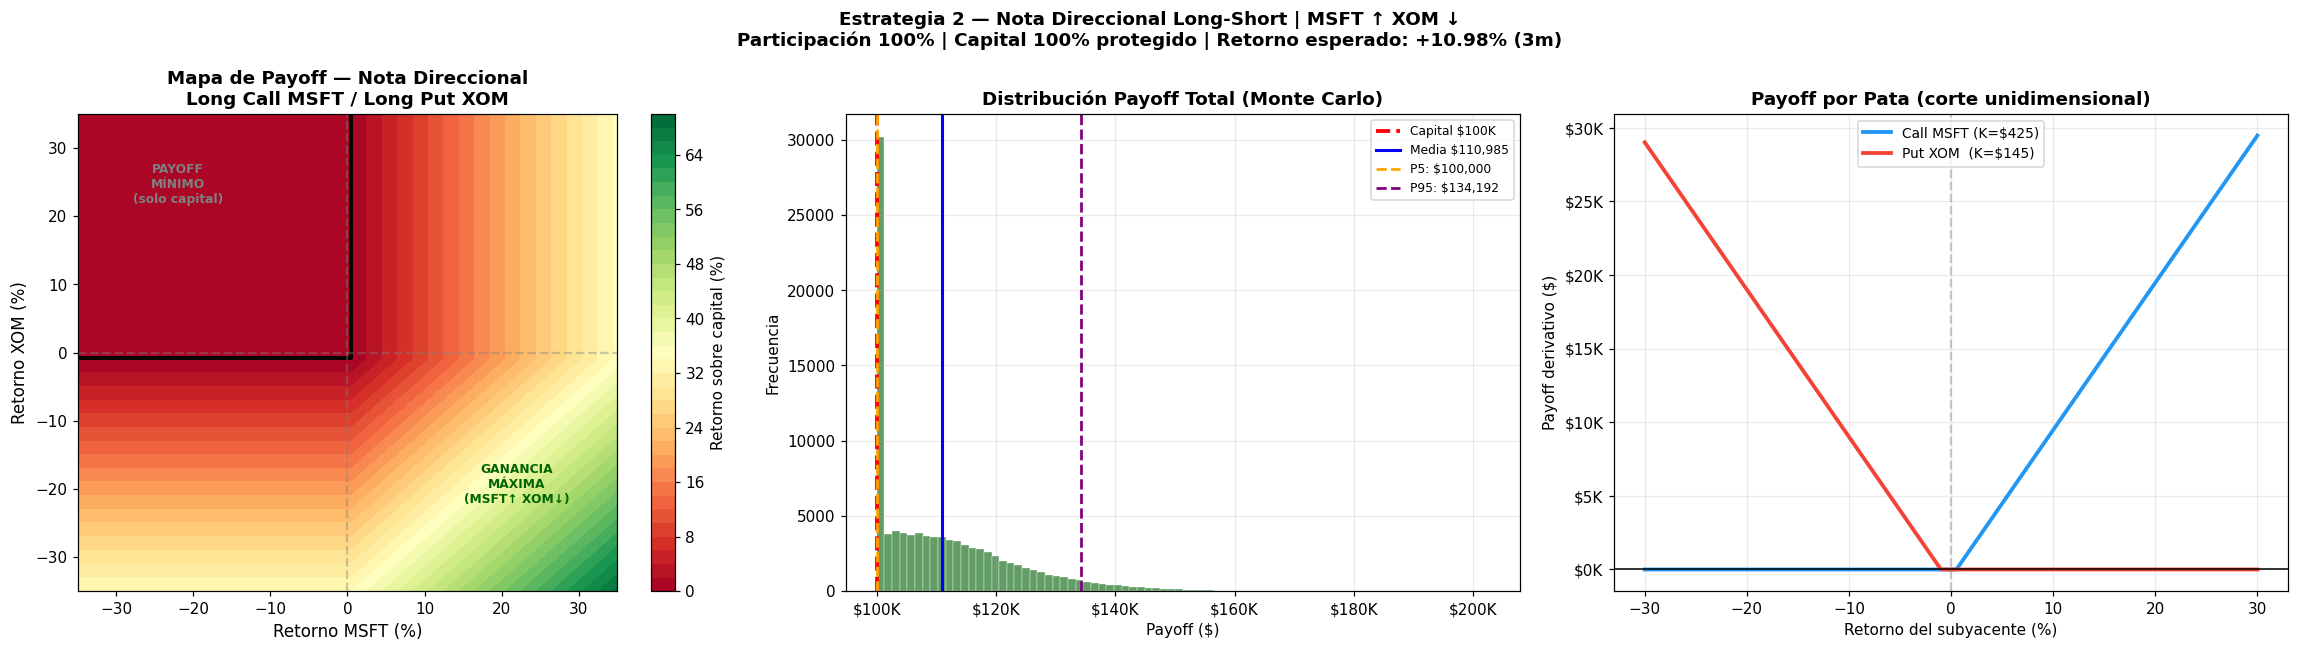

In [86]:
msft_rets = np.linspace(-0.35, 0.35, 220)
xom_rets  = np.linspace(-0.35, 0.35, 220)
M2, X2    = np.meshgrid(msft_rets, xom_rets)

ST_M_grid = S0_MSFT * (1 + M2)
ST_X_grid = S0_XOM  * (1 + X2)

payoff_grid, _, _, deriv_grid = directional_ls_payoff(
    ST_M_grid, ST_X_grid, S0_MSFT, S0_XOM, K_MSFT, K_XOM, NOTIONAL, S2_PARTICIPATION
)
ret_grid = deriv_grid / NOTIONAL * 100

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Panel 1: Mapa de calor del payoff
ax = axes[0]
im = ax.contourf(M2*100, X2*100, ret_grid, levels=35, cmap='RdYlGn')
ax.contour(M2*100, X2*100, ret_grid, levels=[0], colors='black', linewidths=2.5)
plt.colorbar(im, ax=ax, label='Retorno sobre capital (%)')
ax.set_xlabel('Retorno MSFT (%)', fontsize=11)
ax.set_ylabel('Retorno XOM (%)', fontsize=11)
ax.set_title('Mapa de Payoff — Nota Direccional\nLong Call MSFT / Long Put XOM', fontweight='bold')
ax.axhline(0, color='gray', ls='--', alpha=0.4)
ax.axvline(0, color='gray', ls='--', alpha=0.4)
ax.text(22, -22, 'GANANCIA\nMÁXIMA\n(MSFT↑ XOM↓)', color='darkgreen',
        fontweight='bold', ha='center', fontsize=8)
ax.text(-22, 22, 'PAYOFF\nMÍNIMO\n(solo capital)', color='gray',
        fontweight='bold', ha='center', fontsize=8)

# Panel 2: Distribución Monte Carlo
ax = axes[1]
ax.hist(payoff2, bins=80, color='#2E7D32', alpha=0.75, edgecolor='white', linewidth=0.3)
ax.axvline(NOTIONAL,              color='red',    ls='--', lw=2.5, label=f'Capital ${NOTIONAL/1000:.0f}K')
ax.axvline(payoff2.mean(),        color='blue',   ls='-',  lw=2,   label=f'Media ${payoff2.mean():,.0f}')
ax.axvline(np.percentile(payoff2,  5), color='orange', ls='--', lw=1.8, label=f'P5: ${np.percentile(payoff2,5):,.0f}')
ax.axvline(np.percentile(payoff2, 95), color='purple', ls='--', lw=1.8, label=f'P95: ${np.percentile(payoff2,95):,.0f}')
ax.set_title('Distribución Payoff Total (Monte Carlo)', fontweight='bold')
ax.set_xlabel('Payoff ($)')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Panel 3: Payoff por pata (corte unidimensional)
ax = axes[2]
rng_1d   = np.linspace(-0.30, 0.30, 500)
call_1d  = np.maximum(S0_MSFT*(1+rng_1d) - K_MSFT, 0) / S0_MSFT * NOTIONAL
put_1d   = np.maximum(K_XOM - S0_XOM*(1+rng_1d), 0) / S0_XOM * NOTIONAL
ax.plot(rng_1d*100,  call_1d, lw=2.5, color='#2196F3', label=f'Call MSFT (K=${K_MSFT:.0f})')
ax.plot(rng_1d*100,  put_1d,  lw=2.5, color='#F44336', label=f'Put XOM  (K=${K_XOM:.0f})')
ax.axhline(0, color='black', lw=1)
ax.axvline(0, color='gray', ls='--', alpha=0.4)
ax.set_title('Payoff por Pata (corte unidimensional)', fontweight='bold')
ax.set_xlabel('Retorno del subyacente (%)')
ax.set_ylabel('Payoff derivativo ($)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.suptitle(
    f'Estrategia 2 — Nota Direccional Long-Short | MSFT ↑ XOM ↓\n'
    f'Participación 100% | Capital 100% protegido | '
    f'Retorno esperado: {exp_ret2*100:+.2f}% (3m)',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## S2-E. Tabla de Escenarios Numéricos

Análisis determinista de 11 escenarios representativos para comunicar el producto al inversor:

| Tipo | Descripción |
|---|---|
| **Mejor caso** | MSFT +20% / XOM -20% → ambas patas ganan → máximo payoff |
| **Tesis parcial** | Solo MSFT sube o solo XOM baja → una pata contribuye |
| **Mercado alcista** | Ambos suben → solo la call gana → payoff moderado |
| **Mercado bajista** | Ambos bajan → solo la put gana → payoff moderado |
| **Anti-tesis** | MSFT baja, XOM sube → ninguna pata ejerce → se devuelve exactamente el capital |
| **Sin movimiento** | Flat → capital exactamente recuperado ($100,000) |


In [87]:
print("\n" + "=" * 90)
print("  ANÁLISIS DE ESCENARIOS — NOTA DIRECCIONAL LONG-SHORT")
print("=" * 90)

scenarios_s2 = [
    ( 0.20, -0.20, "Escenario 1: MSFT +20% / XOM -20%  ← MEJOR CASO"),
    ( 0.15, -0.15, "Escenario 1b: MSFT +15% / XOM -15%"),
    ( 0.05, -0.05, "Escenario 2: MSFT +5% / XOM -5% (leve)"),
    ( 0.10,  0.00, "MSFT +10% / XOM flat"),
    ( 0.00, -0.10, "MSFT flat / XOM -10%"),
    ( 0.10,  0.10, "Ambos +10% (mercado sube)"),
    (-0.10, -0.10, "Ambos -10% (mercado baja)"),
    (-0.05,  0.05, "Escenario 3: MSFT -5% / XOM +5%  ← PEOR TESIS"),
    (-0.15,  0.15, "MSFT -15% / XOM +15%  ← peor escenario"),
    ( 0.00,  0.00, "Sin movimiento (flat)"),
    ( 0.25, -0.25, "Rally extremo pro-tesis"),
]

rows_s2 = []
for ret_m, ret_x, desc in scenarios_s2:
    st_m = S0_MSFT * (1 + ret_m)
    st_x = S0_XOM  * (1 + ret_x)
    call_iv   = max(st_m - K_MSFT, 0)
    put_iv    = max(K_XOM - st_x, 0)
    call_norm = call_iv / S0_MSFT
    put_norm  = put_iv  / S0_XOM
    deriv_ret = S2_PARTICIPATION * max(call_norm + put_norm, 0)
    deriv_usd = NOTIONAL * deriv_ret
    total_pay = NOTIONAL + deriv_usd
    rows_s2.append({
        'Escenario':     desc,
        'MSFT ret':      f'{ret_m*100:+.0f}%',
        'XOM ret':       f'{ret_x*100:+.0f}%',
        'ST_MSFT':       f'${st_m:,.2f}',
        'ST_XOM':        f'${st_x:,.2f}',
        'Call IV (MSFT)':f'${call_iv:,.2f}',
        'Put IV (XOM)':  f'${put_iv:,.2f}',
        'Deriv %':       f'{deriv_ret*100:+.2f}%',
        'Payoff':        f'${total_pay:,.0f}',
        'Rend. 3m':      f'{(total_pay/NOTIONAL-1)*100:+.2f}%',
        'Resultado':     '✅ Ganancia' if total_pay > NOTIONAL else '⬜ Solo capital',
    })

df_s2 = pd.DataFrame(rows_s2)
print(df_s2.to_string(index=False))
df_s2


  ANÁLISIS DE ESCENARIOS — NOTA DIRECCIONAL LONG-SHORT
                                      Escenario MSFT ret XOM ret ST_MSFT  ST_XOM Call IV (MSFT) Put IV (XOM) Deriv %   Payoff Rend. 3m      Resultado
Escenario 1: MSFT +20% / XOM -20%  ← MEJOR CASO     +20%    -20% $507.35 $117.15         $82.35       $27.85 +38.49% $138,494  +38.49%     ✅ Ganancia
             Escenario 1b: MSFT +15% / XOM -15%     +15%    -15% $486.21 $124.47         $61.21       $20.53 +28.49% $128,494  +28.49%     ✅ Ganancia
         Escenario 2: MSFT +5% / XOM -5% (leve)      +5%     -5% $443.93 $139.12         $18.93        $5.88  +8.49% $108,494   +8.49%     ✅ Ganancia
                           MSFT +10% / XOM flat     +10%     +0% $465.07 $146.44         $40.07        $0.00  +9.48% $109,477   +9.48%     ✅ Ganancia
                           MSFT flat / XOM -10%      +0%    -10% $422.79 $131.80          $0.00       $13.20  +9.02% $109,017   +9.02%     ✅ Ganancia
                      Ambos +10% (mercado su

,Escenario,MSFT ret,XOM ret,ST_MSFT,ST_XOM,Call IV (MSFT),Put IV (XOM),Deriv %,Payoff,Rend. 3m,Resultado
0,Escenario 1: MSFT +20% / XOM -20% ← MEJOR CASO,+20%,-20%,$507.35,$117.15,$82.35,$27.85,+38.49%,"$138,494",+38.49%,✅ Ganancia
1,Escenario 1b: MSFT +15% / XOM -15%,+15%,-15%,$486.21,$124.47,$61.21,$20.53,+28.49%,"$128,494",+28.49%,✅ Ganancia
2,Escenario 2: MSFT +5% / XOM -5% (leve),+5%,-5%,$443.93,$139.12,$18.93,$5.88,+8.49%,"$108,494",+8.49%,✅ Ganancia
3,MSFT +10% / XOM flat,+10%,+0%,$465.07,$146.44,$40.07,$0.00,+9.48%,"$109,477",+9.48%,✅ Ganancia
4,MSFT flat / XOM -10%,+0%,-10%,$422.79,$131.80,$0.00,$13.20,+9.02%,"$109,017",+9.02%,✅ Ganancia
5,Ambos +10% (mercado sube),+10%,+10%,$465.07,$161.08,$40.07,$0.00,+9.48%,"$109,477",+9.48%,✅ Ganancia
6,Ambos -10% (mercado baja),-10%,-10%,$380.51,$131.80,$0.00,$13.20,+9.02%,"$109,017",+9.02%,✅ Ganancia
7,Escenario 3: MSFT -5% / XOM +5% ← PEOR TESIS,-5%,+5%,$401.65,$153.76,$0.00,$0.00,+0.00%,"$100,000",+0.00%,⬜ Solo capital
8,MSFT -15% / XOM +15% ← peor escenario,-15%,+15%,$359.37,$168.41,$0.00,$0.00,+0.00%,"$100,000",+0.00%,⬜ Solo capital
9,Sin movimiento (flat),+0%,+0%,$422.79,$146.44,$0.00,$0.00,+0.00%,"$100,000",+0.00%,⬜ Solo capital


## S2-F. Análisis de Primas y Factibilidad de Estructuración

La pregunta central desde el punto de vista del estructurador:

> **¿El costo total de las opciones (Call MSFT + Put XOM) cabe dentro del presupuesto disponible ($N - \text{VP}_{ZCB}$)?**

### Condición de factibilidad a la par

$$\text{Cost}_{call} + \text{Cost}_{put} \leq \underbrace{N - N \cdot e^{-rT}}_{\text{Presupuesto de opciones}}$$

Si el costo excede el presupuesto, las soluciones disponibles son:
1. **Strikes más OTM** — reducen la prima pero bajan la probabilidad de ejercicio.
2. **Reducir la participación** por debajo del 100%.
3. **Emitir la nota con descuento** (precio de venta < $100,000).

### Análisis del spread bid/ask

El spread como porcentaje del mid-price mide el **costo de liquidez implícito** que paga el banco al comprar las opciones en el mercado secundario. Un spread amplio indica menor liquidez y mayor costo real de la estructura.


In [88]:
print("\n" + "=" * 70)
print("  ANÁLISIS DE PRIMAS Y FACTIBILIDAD DE ESTRUCTURACIÓN")
print("=" * 70)

print(f"\n  Long Call MSFT (K=${K_MSFT:.2f}):")
print(f"    Precio BS teórico:   ${bs_price_call_msft:>10.2f}")
print(f"    Costo de compra:     ${cost_call_msft:>10.2f}  ({'ask de mercado' if using_market_msft else 'BS teórico'})")
if using_market_msft:
    spread_call = S2_MSFT_CALL_ASK - S2_MSFT_CALL_BID
    print(f"    Spread bid/ask:      ${spread_call:>10.2f}  ({spread_call/market_mid_call*100:.1f}% del mid)")

print(f"\n  Long Put XOM (K=${K_XOM:.2f}):")
print(f"    Precio BS teórico:   ${bs_price_put_xom:>10.2f}")
print(f"    Costo de compra:     ${cost_put_xom:>10.2f}  ({'ask de mercado' if using_market_xom else 'BS teórico'})")
if using_market_xom:
    spread_put = S2_XOM_PUT_ASK - S2_XOM_PUT_BID
    print(f"    Spread bid/ask:      ${spread_put:>10.2f}  ({spread_put/market_mid_put*100:.1f}% del mid)")

print(f"\n  TOTALES:")
print(f"    Costo opciones:        ${total_option_cost:>10.2f}")
print(f"    Presupuesto (N - ZCB): ${option_budget2:>10.2f}")
print(f"    Margen / Excedente:    ${option_budget2 - total_option_cost:>+10.2f}")
viable = total_option_cost <= option_budget2
print(f"\n  {'✅ VIABLE: primas dentro del presupuesto' if viable else '⚠️ NO VIABLE: ajustar strikes OTM o ampliar plazo'}")

print(f"""
  Notas sobre primas y trade-offs:
  • Spreads bid/ask estrechos → mayor liquidez (opciones ATM, vencimientos estándar).
  • Strikes OTM → primas más baratas, mayor movimiento requerido para ganar.
  • Strikes ITM → primas más caras, valor intrínseco inicial, mayor prob. de ganancia.
  • Mayor plazo T → primas más caras, más convexidad, pero ZCB rinde más.
  • Correlación negativa MSFT/XOM beneficia la estructura: ambas patas ganan juntas.""")

corr_msft_xom = returns_all[['MSFT', 'XOM']].corr().loc['MSFT', 'XOM']
print(f"\n  Correlación histórica MSFT / XOM: {corr_msft_xom:.3f}")
print(f"  {'→ Correlación baja/negativa — estructura favorecida ✅' if corr_msft_xom < 0.3 else '→ Correlación moderada/alta — diversificación limitada'}")


  ANÁLISIS DE PRIMAS Y FACTIBILIDAD DE ESTRUCTURACIÓN

  Long Call MSFT (K=$425.00):
    Precio BS teórico:   $     24.75
    Costo de compra:     $     26.50  (ask de mercado)
    Spread bid/ask:      $      0.50  (1.9% del mid)

  Long Put XOM (K=$145.00):
    Precio BS teórico:   $      7.66
    Costo de compra:     $      7.65  (ask de mercado)
    Spread bid/ask:      $      0.25  (3.3% del mid)

  TOTALES:
    Costo opciones:        $     34.15
    Presupuesto (N - ZCB): $    900.92
    Margen / Excedente:    $   +866.77

  ✅ VIABLE: primas dentro del presupuesto

  Notas sobre primas y trade-offs:
  • Spreads bid/ask estrechos → mayor liquidez (opciones ATM, vencimientos estándar).
  • Strikes OTM → primas más baratas, mayor movimiento requerido para ganar.
  • Strikes ITM → primas más caras, valor intrínseco inicial, mayor prob. de ganancia.
  • Mayor plazo T → primas más caras, más convexidad, pero ZCB rinde más.
  • Correlación negativa MSFT/XOM beneficia la estructura: amba

## S2-G. Distribución del Payoff Total del Inversor

### Interpretación del histograma Monte Carlo

- **Pico alto en $100,000:** Gran masa de escenarios donde ninguna opción ejerce valor → el inversor recibe exactamente su capital. Este pico representa el "piso" de la distribución y es la materialización visual de la garantía de capital.
- **Cola derecha positiva:** Escenarios donde la tesis funciona (MSFT sube, XOM baja) → el inversor recibe más que su capital. La longitud de la cola refleja el potencial de ganancia de la estrategia.
- **Sin cola izquierda:** La distribución está truncada en $100,000 → garantía verificada empíricamente en los 100,000 escenarios.

El gráfico de la derecha compara la distribución de la nota con la **inversión directa equivalente** (misma exposición a MSFT y XOM, sin protección de capital). La inversión directa tiene cola izquierda (puede perder), pero captura el upside completo sin cap.


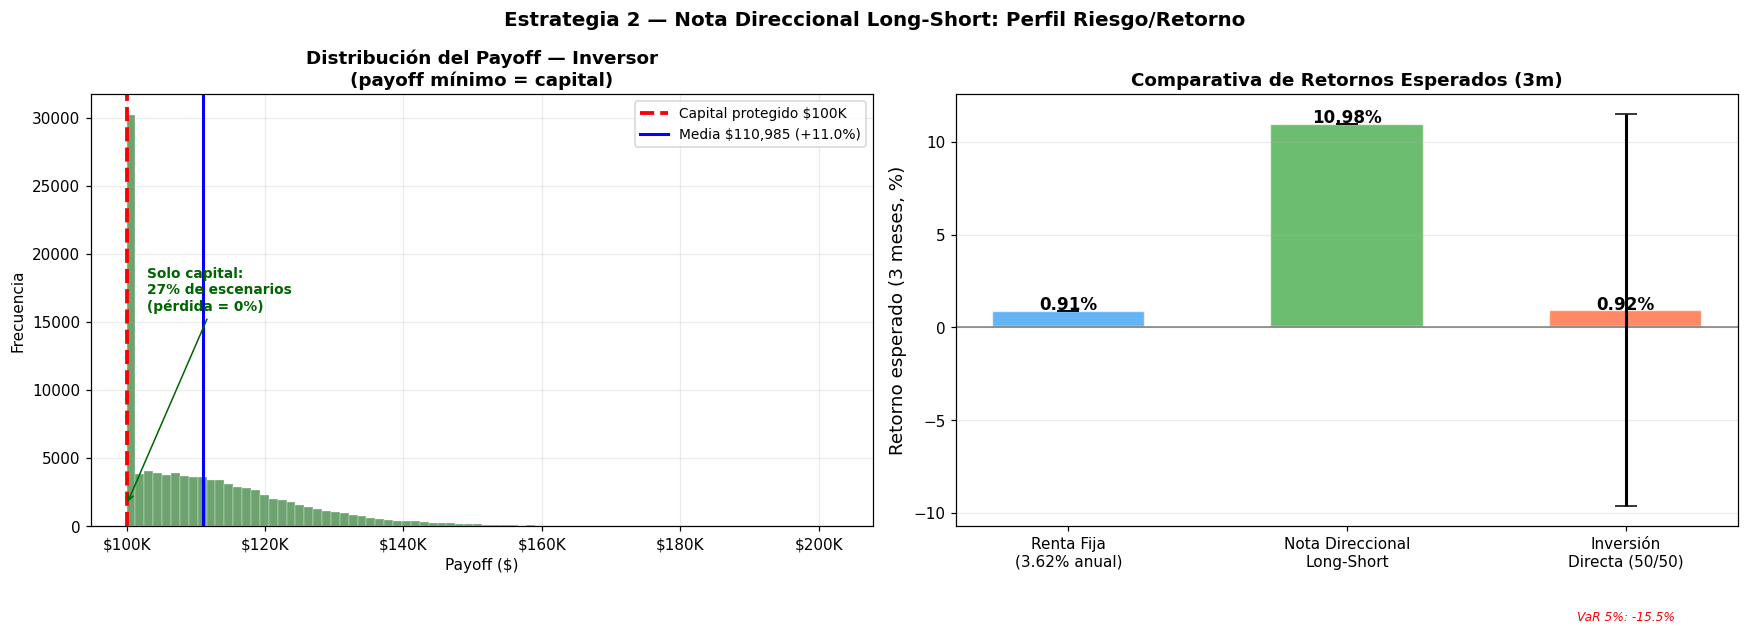

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Histograma del payoff
ax = axes[0]
ax.hist(payoff2, bins=80, color='#2E7D32', alpha=0.7, edgecolor='white', linewidth=0.3)
ax.axvline(NOTIONAL,       color='red',  ls='--', lw=2.5, label=f'Capital protegido ${NOTIONAL/1000:.0f}K')
ax.axvline(payoff2.mean(), color='blue', ls='-',  lw=2,
           label=f'Media ${payoff2.mean():,.0f} ({exp_ret2*100:+.1f}%)')
only_capital_pct = (payoff2 <= NOTIONAL + 1).mean() * 100
ax.annotate(f'Solo capital:\n{only_capital_pct:.0f}% de escenarios\n(pérdida = 0%)',
            xy=(NOTIONAL, ax.get_ylim()[1]*0.05 if ax.get_ylim()[1] > 0 else 1000),
            xytext=(NOTIONAL * 1.03, ax.get_ylim()[1]*0.5 if ax.get_ylim()[1] > 0 else 5000),
            fontsize=9, color='darkgreen', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='darkgreen'))
ax.set_title('Distribución del Payoff — Inversor\n(payoff mínimo = capital)', fontweight='bold')
ax.set_xlabel('Payoff ($)')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Panel 2: Comparativa retornos esperados
ax2 = axes[1]
rf_return    = RISK_FREE * T * 100
note_return  = exp_ret2 * 100
direct_sim   = 0.5 * (finals2[:, 0]/S0_MSFT - 1) + 0.5 * (finals2[:, 1]/S0_XOM - 1)
direct_mean  = float(direct_sim.mean()) * 100
direct_std   = float(direct_sim.std()) * 100
direct_worst = float(np.percentile(direct_sim, 5)) * 100

strat_labels = ['Renta Fija\n(3.62% anual)', 'Nota Direccional\nLong-Short', 'Inversión\nDirecta (50/50)']
bar_vals     = [rf_return, note_return, direct_mean]
bcolors      = ['#42A5F5', '#4CAF50', '#FF7043']

bars2 = ax2.bar(strat_labels, bar_vals, color=bcolors, alpha=0.82,
                edgecolor='white', linewidth=1.5, width=0.55)
ax2.errorbar(strat_labels, bar_vals, yerr=[0, 0, direct_std],
             fmt='none', color='black', capsize=7, linewidth=2)
for bar, val in zip(bars2, bar_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, max(val, 0) + 0.05,
             f'{val:.2f}%', ha='center', fontweight='bold', fontsize=11)
ax2.text(2, direct_worst - 0.35, f'VaR 5%: {direct_worst:.1f}%',
         ha='center', fontsize=8, color='red', style='italic')
ax2.axhline(0, color='black', lw=1, alpha=0.5)
ax2.set_ylabel('Retorno esperado (3 meses, %)', fontsize=12)
ax2.set_title('Comparativa de Retornos Esperados (3m)', fontweight='bold')
ax2.grid(True, alpha=0.25, axis='y')

plt.suptitle('Estrategia 2 — Nota Direccional Long-Short: Perfil Riesgo/Retorno',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## S2-H. Descomposición de la Nota y Perfil de Ganancia

### Panel 1 — Descomposición por componentes (a lo largo de la tesis)

Muestra cómo se distribuye el valor de la nota cuando el mercado sigue la tesis canónica (MSFT sube α%, XOM baja α% simultáneamente):
- **Azul claro:** Bono ZCB — base fija que garantiza el capital, siempre = $100,000.
- **Verde:** Ganancia de la Call MSFT — crece cuando α > 0 y MSFT supera su strike.
- **Rojo claro:** Ganancia de la Put XOM — crece cuando α > 0 y XOM cae por debajo de su strike.

A mayor amplitud de la divergencia (mayor α), ambas patas contribuyen más y la ganancia total crece.

### Panel 2 — Perfil de ganancia neta del inversor

Muestra la **ganancia neta** (payoff − capital) para todos los escenarios del espacio bidimensional (MSFT, XOM). La región verde representa todos los escenarios donde el inversor recibe más que su capital. El tamaño y forma de la región verde es función de los strikes elegidos y de la correlación histórica entre los dos activos.


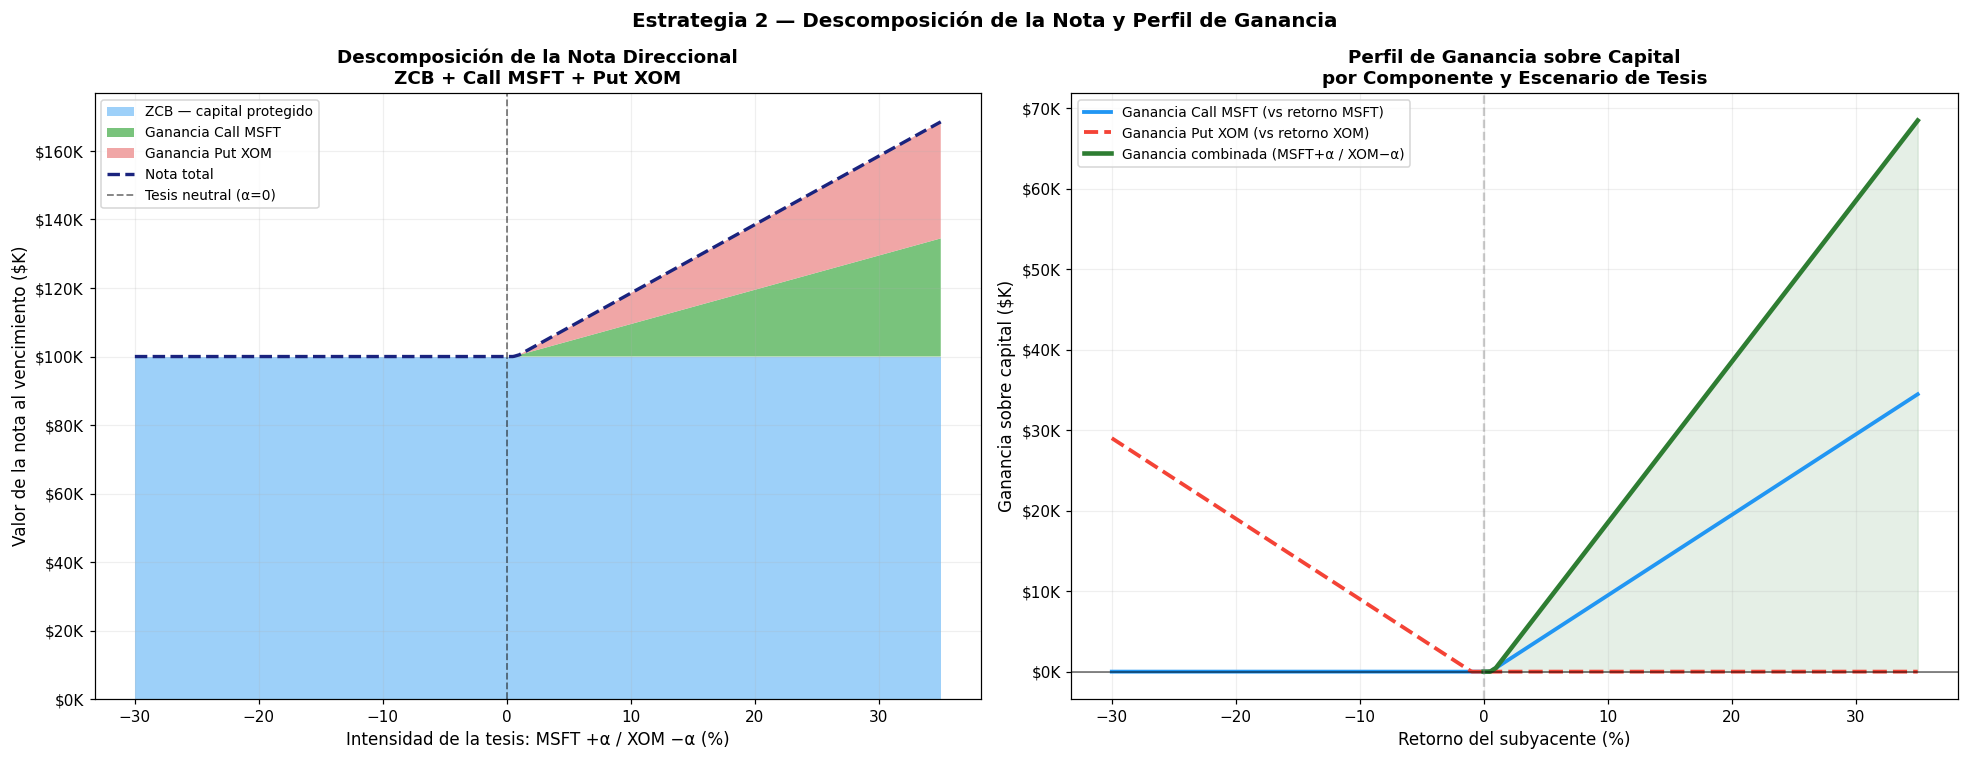

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Panel 1: Descomposición de componentes (escenario tesis: MSFT+α / XOM-α) ──
ax = axes[0]
alpha = np.linspace(-0.30, 0.35, 500)
ST_M_a = S0_MSFT * (1 + alpha)
ST_X_a = S0_XOM  * (1 - alpha)

zcb_comp  = np.full(len(alpha), NOTIONAL)
call_comp = np.maximum(ST_M_a - K_MSFT, 0) / S0_MSFT * NOTIONAL * S2_PARTICIPATION
put_comp  = np.maximum(K_XOM  - ST_X_a, 0) / S0_XOM  * NOTIONAL * S2_PARTICIPATION

ax.stackplot(
    alpha * 100,
    zcb_comp  / 1000,
    call_comp / 1000,
    put_comp  / 1000,
    labels=['ZCB — capital protegido', 'Ganancia Call MSFT', 'Ganancia Put XOM'],
    colors=['#90CAF9', '#66BB6A', '#EF9A9A'],
    alpha=0.88
)
total_comp = (zcb_comp + call_comp + put_comp) / 1000
ax.plot(alpha * 100, total_comp, lw=2.2, color='#1A237E', ls='--', label='Nota total')
ax.axvline(0, color='black', ls='--', lw=1.2, alpha=0.5, label='Tesis neutral (α=0)')
ax.set_xlabel('Intensidad de la tesis: MSFT +α / XOM −α (%)', fontsize=11)
ax.set_ylabel('Valor de la nota al vencimiento ($K)', fontsize=11)
ax.set_title('Descomposición de la Nota Direccional\nZCB + Call MSFT + Put XOM', fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.2)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}K'))

# ── Panel 2: Ganancia sobre capital por componente y escenario ───────────────
ax2 = axes[1]
rng = np.linspace(-0.30, 0.35, 500)

# Solo Call MSFT (XOM flat)
call_gain = np.maximum(S0_MSFT*(1+rng) - K_MSFT, 0) / S0_MSFT * NOTIONAL * S2_PARTICIPATION
# Solo Put XOM (MSFT flat) — gana cuando retorno de XOM es negativo
put_gain  = np.maximum(K_XOM - S0_XOM*(1+rng), 0)  / S0_XOM  * NOTIONAL * S2_PARTICIPATION
# Tesis combinada: MSFT +α / XOM -α (alpha positivo = tesis se cumple)
alpha_pos = np.linspace(0, 0.35, 500)
call_t = np.maximum(S0_MSFT*(1+alpha_pos) - K_MSFT, 0) / S0_MSFT * NOTIONAL * S2_PARTICIPATION
put_t  = np.maximum(K_XOM - S0_XOM*(1-alpha_pos), 0) / S0_XOM  * NOTIONAL * S2_PARTICIPATION
comb_t = call_t + put_t

ax2.plot(rng*100, call_gain/1000, lw=2.5, color='#2196F3',
         label='Ganancia Call MSFT (vs retorno MSFT)')
ax2.plot(rng*100, put_gain/1000,  lw=2.5, color='#F44336', ls='--',
         label='Ganancia Put XOM (vs retorno XOM)')
ax2.plot(alpha_pos*100, comb_t/1000, lw=3, color='#2E7D32',
         label='Ganancia combinada (MSFT+α / XOM−α)')
ax2.fill_between(alpha_pos*100, comb_t/1000, 0,
                 where=comb_t > 0, alpha=0.12, color='#2E7D32')
ax2.axhline(0, color='black', lw=1, alpha=0.6)
ax2.axvline(0, color='gray', ls='--', alpha=0.4)
ax2.set_xlabel('Retorno del subyacente (%)', fontsize=11)
ax2.set_ylabel('Ganancia sobre capital ($K)', fontsize=11)
ax2.set_title('Perfil de Ganancia sobre Capital\npor Componente y Escenario de Tesis', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.2)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}K'))

plt.suptitle(
    'Estrategia 2 — Descomposición de la Nota y Perfil de Ganancia',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

---
# 🟪 ESTRATEGIA 3 · PPN Bull Call Spread sobre Basket (JPM · WMT · MSFT)

## Concepto y motivación

La **PPN (Principal Protected Note) con Bull Call Spread** es la estructura más eficiente en términos de costo/participación. El subyacente es un **basket de mínima varianza** de tres sectores diferentes: JPMorgan Chase (finanzas), Walmart (consumo defensivo) y Microsoft (tecnología).

### ¿Por qué un basket de mínima varianza?

La diversificación reduce la volatilidad del basket: $\sigma_{basket} < \bar{\sigma}_{activos}$ cuando las correlaciones son menores a 1. Menor volatilidad implica **opciones más baratas**, lo que permite mayor participación o mayor cap dentro del mismo presupuesto de opciones.

### Estructura

| Pata | Instrumento | Función |
|---|---|---|
| **Base** | Bono cero cupón 6M | Garantiza devolver $100,000 al vencimiento |
| **Pata 1** | Long Call ATM sobre basket | Captura el upside del basket cuando sube |
| **Pata 2** | Short Call OTM sobre basket (cap 15%) | Vende el upside extremo para financiar la estructura |

### Fórmula del payoff

$$\text{Payoff} = N \times \left(1 + P \times \min\left(\max\left(R_{basket}, 0\right),\, 15\%\right)\right)$$

Donde $R_{basket} = (\text{Basket}_T - \text{Basket}_0)/\text{Basket}_0$ es el retorno del basket ponderado y $P = 60\%$ es la participación.

### Ventaja del Bull Call Spread vs. Call simple

| Estructura | Prima neta | Cap de ganancia | Participación lograda |
|---|---|---|---|
| Long Call simple | Mayor | Ilimitado | Menor (presupuesto limitado) |
| **Bull Call Spread** | **Menor** | **15%** | **Mayor (60% vs. ~35%)** |

El spread sacrifica el upside extremo (>15%) a cambio de una prima neta que cabe en el presupuesto del ZCB, permitiendo una participación mucho mayor.


In [91]:
# Cargar datos de mercado para S3 desde el dataset ya descargado
# (no es necesaria una nueva descarga — se reusa prices_all y returns_all)
# ── Parámetros S3 definidos en la celda de Parámetros Globales ──────────────

# ── Datos de mercado desde prices_all (ya descargado) ────────────────────────
spots_s3      = np.array([float(spots[t]) for t in TICKERS_S3])
vols_s3_hist  = np.array([float(vols_all[t]) for t in TICKERS_S3])
corr_s3       = returns_all[TICKERS_S3].corr().values

print("=" * 60)
print("  ESTRATEGIA 3 — PPN Bull Call Spread")
print("  Basket: JPM · WMT · MSFT | Capital 100% protegido")
print("=" * 60)
print(f"\n  {'Ticker':6s}  {'Spot':>10s}  {'Vol anual':>10s}")
for t, s, v in zip(TICKERS_S3, spots_s3, vols_s3_hist):
    print(f"  {t:6s}  ${s:>9.2f}  {v*100:>9.1f}%")
print(f"\n  Cap del spread:      {S3_CAP*100:.0f}%")
print(f"  Participación:       {S3_PARTICIPATION*100:.0f}%")
print(f"  Plazo:               {S3_T*12:.0f} meses")
print(f"  Tasa libre de riesgo:{S3_RISK_FREE*100:.2f}% (6m)")

  ESTRATEGIA 3 — PPN Bull Call Spread
  Basket: JPM · WMT · MSFT | Capital 100% protegido

  Ticker        Spot   Vol anual
  JPM     $   310.29       25.0%
  WMT     $   127.50       25.4%
  MSFT    $   422.79       26.6%

  Cap del spread:      15%
  Participación:       60%
  Plazo:               6 meses
  Tasa libre de riesgo:3.58% (6m)


## S3-A. Portafolio de Mínima Varianza — Basket JPM · WMT · MSFT

Se construye el portafolio de mínima varianza que determina los **pesos de cada acción en el basket**. Estos pesos son los mismos que se usan para:
1. Calcular el valor actual del basket ($\text{Basket}_0 = \sum_i w_i S_0^{(i)}$).
2. Calcular el valor del basket en cada simulación Monte Carlo.
3. Determinar los strikes de las opciones (ATM: $K_1 = \text{Basket}_0$, OTM: $K_2 = \text{Basket}_0 \times 1.15$).

### Volatilidad del basket

La volatilidad anualizada del basket es:
$$\sigma_{basket} = \sqrt{\mathbf{w}^\top \Sigma \mathbf{w}}$$

Al minimizar esta expresión con la optimización de Markowitz, se obtiene el basket con **menor volatilidad posible** dado el universo de activos, lo que maximiza la eficiencia del presupuesto de opciones.


  PORTAFOLIO MÍNIMA VARIANZA — BASKET S3
  JPM: 30.10%
  WMT: 38.86%
  MSFT: 31.04%

  Retorno esperado anual:    +21.48%
  Volatilidad anual:          18.45%
  Sharpe ratio:               0.968

  Basket spot ponderado:     $274.1800
  Volatilidad del basket:     18.45%
  Div yield ponderado:        1.389%


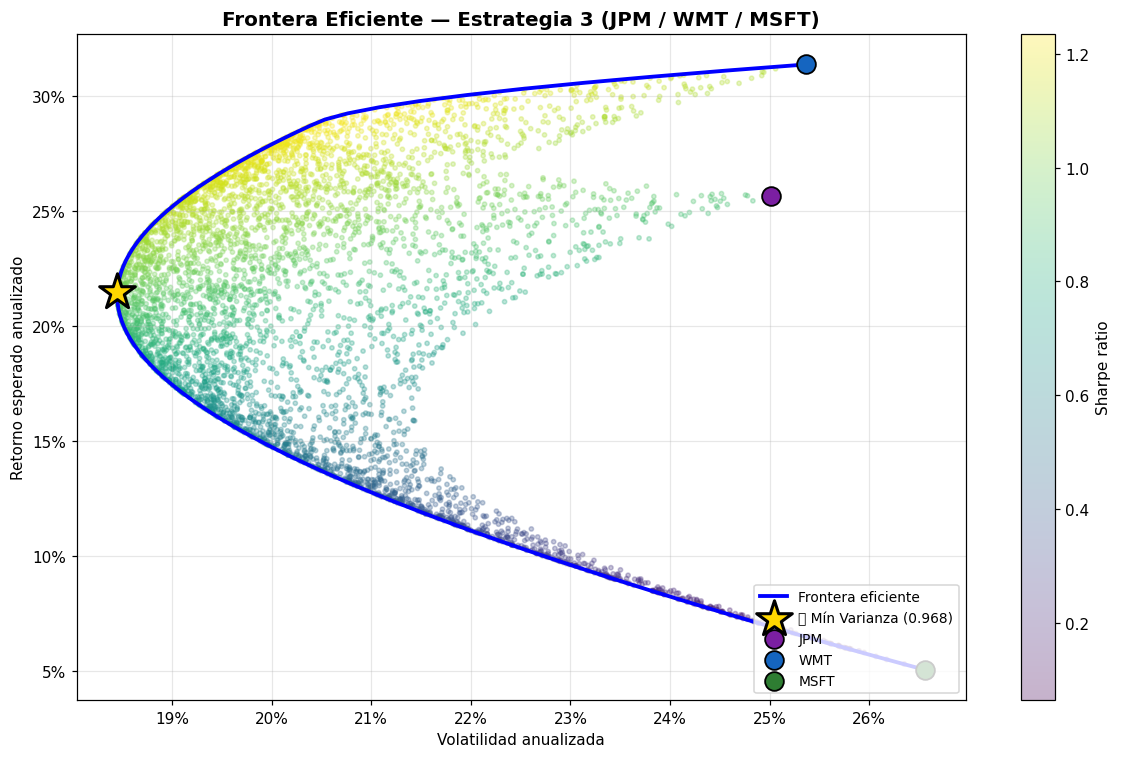

In [92]:
# Calcular covarianza y retornos esperados anualizados para el basket S3
ret3  = returns_all[TICKERS_S3]
cov3  = ret3.cov() * 252
mu3   = ret3.mean() * 252
n3    = len(TICKERS_S3)

weights_s3 = optimize_minvar(cov3, n3)
ret_s3, std_s3 = portfolio_perf(weights_s3, mu3, cov3)

# Basket spot (ponderado por pesos) y parámetros para opciones
basket_spot = float(weights_s3 @ spots_s3)
vol_basket  = float(np.sqrt(weights_s3 @ cov3.values @ weights_s3))
div_basket  = float(sum(weights_s3[i] * S3_DIV[t] for i, t in enumerate(TICKERS_S3)))

print("=" * 60)
print("  PORTAFOLIO MÍNIMA VARIANZA — BASKET S3")
print("=" * 60)
for t, w in zip(TICKERS_S3, weights_s3):
    print(f"  {t}: {w*100:.2f}%")
print(f"\n  Retorno esperado anual:    {ret_s3*100:+.2f}%")
print(f"  Volatilidad anual:          {std_s3*100:.2f}%")
print(f"  Sharpe ratio:               {(ret_s3 - RISK_FREE)/std_s3:.3f}")
print(f"\n  Basket spot ponderado:     ${basket_spot:.4f}")
print(f"  Volatilidad del basket:     {vol_basket*100:.2f}%")
print(f"  Div yield ponderado:        {div_basket*100:.3f}%")

# ── Frontera eficiente S3 ─────────────────────────────────────────────────────
ef_ret3, ef_vol3 = efficient_frontier(mu3, cov3)
np.random.seed(SEED)
rw3 = np.random.dirichlet(np.ones(n3), 5000)
rr3 = rw3 @ mu3.values
rs3 = np.sqrt(np.einsum('ij,jk,ik->i', rw3, cov3.values, rw3))
r_mv3, s_mv3 = portfolio_perf(weights_s3, mu3, cov3)

fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(rs3, rr3, c=(rr3 - RISK_FREE) / rs3, cmap='viridis', alpha=0.3, s=8)
plt.colorbar(sc, label='Sharpe ratio')
ax.plot(ef_vol3, ef_ret3, 'b-', lw=2.5, label='Frontera eficiente')
ax.scatter(s_mv3, r_mv3, marker='*', s=600, c='gold', edgecolors='k', lw=2, zorder=6,
           label=f"✅ Mín Varianza ({(r_mv3 - RISK_FREE)/s_mv3:.3f})")
colors_s3_pts = ['#7B1FA2', '#1565C0', '#2E7D32']
for i, (t, c) in enumerate(zip(TICKERS_S3, colors_s3_pts)):
    ax.scatter(np.sqrt(cov3.iloc[i, i]), mu3.iloc[i], marker='o', s=150,
               color=c, edgecolors='k', lw=1.2, label=t, zorder=4)
ax.set_xlabel('Volatilidad anualizada')
ax.set_ylabel('Retorno esperado anualizado')
ax.set_title('Frontera Eficiente — Estrategia 3 (JPM / WMT / MSFT)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
plt.tight_layout()
plt.show()

## S3-B. Pricing del Bull Call Spread sobre el Basket

### Construcción del spread

| Leg | Strike | Prima | Rol |
|---|---|---|---|
| **Long Call ATM** | $K_1 = \text{Basket}_0$ | Se paga | Captura el upside del basket |
| **Short Call OTM** | $K_2 = \text{Basket}_0 \times 1.15$ | Se cobra | Define el cap y financia la estructura |

La **prima neta** = Prima Call ATM − Prima Call OTM (siempre positiva, ya que $C_{ATM} > C_{OTM}$ para el mismo subyacente y vencimiento).

### Cálculo de la participación máxima

Dado el presupuesto de opciones $B = N - N \cdot e^{-rT}$, la participación máxima que hace la estructura viable es:

$$P_{max} = \frac{B}{\text{Prima neta del spread} \times N / \text{Basket}_0}$$

Si $P_{max} \geq 1$, se puede ofrecer participación del 100%. En este caso, $P_{max} < 1$ y se ajusta al 60% calculado para que el costo sea exactamente igual al presupuesto.


In [93]:
# Definir strikes del bull call spread y calcular primas Black-Scholes
# ── Strikes ───────────────────────────────────────────────────────────────────
K1_s3 = basket_spot                  # Long Call ATM
K2_s3 = basket_spot * (1 + S3_CAP)  # Short Call OTM (define el cap)

# ── Precios Black-Scholes ─────────────────────────────────────────────────────
bs_call_atm_s3 = price_option('call', K1_s3, basket_spot, vol_basket, S3_RISK_FREE, div_basket, S3_T)
bs_call_otm_s3 = price_option('call', K2_s3, basket_spot, vol_basket, S3_RISK_FREE, div_basket, S3_T)

spread_cost_abs = bs_call_atm_s3 - bs_call_otm_s3
spread_cost_pct = spread_cost_abs / basket_spot

# ── Presupuesto de opciones (ZCB 100% protección de capital) ──────────────────
pv_zcb3        = NOTIONAL * np.exp(-S3_RISK_FREE * S3_T)
option_budget3 = NOTIONAL - pv_zcb3

# ── Participación ajustada al break-even del presupuesto ──────────────────────
# S3_PARTICIPATION en globals es el máximo deseado; aquí se recorta si excede el budget
S3_PARTICIPATION = min(S3_PARTICIPATION, option_budget3 / (NOTIONAL * spread_cost_pct))

cost_spread_s3 = NOTIONAL * S3_PARTICIPATION * spread_cost_pct
margen_s3      = option_budget3 - cost_spread_s3
viable_s3      = cost_spread_s3 <= option_budget3

print("=" * 70)
print("  ESTRATEGIA 3 — PRICING DEL BULL CALL SPREAD")
print("=" * 70)
print(f"\n  Basket spot (S0):             ${basket_spot:>10.4f}")
print(f"  K1 — Long  Call ATM:           ${K1_s3:>10.4f}  (= basket spot)")
print(f"  K2 — Short Call OTM (+{S3_CAP*100:.0f}%):   ${K2_s3:>10.4f}")
print(f"  Volatilidad del basket:        {vol_basket*100:>10.2f}%")
print(f"\n  BS precio Long  Call ATM:     ${bs_call_atm_s3:>10.4f}")
print(f"  BS precio Short Call OTM:     ${bs_call_otm_s3:>10.4f}")
print(f"  Costo neto del spread:        ${spread_cost_abs:>10.4f}  ({spread_cost_pct*100:.3f}% del basket)")
print(f"\n  ESTRUCTURA DE CAPITAL (${NOTIONAL:,} invertidos)")
print(f"    VP del ZCB @ {S3_RISK_FREE*100:.2f}% (6m):    ${pv_zcb3:>12,.2f}")
print(f"    Presupuesto opciones:       ${option_budget3:>12,.2f}")
print(f"    Participación ajustada:     {S3_PARTICIPATION*100:>10.2f}%")
print(f"    Costo spread:               ${cost_spread_s3:>12,.2f}")
print(f"    Margen / Excedente:         ${margen_s3:>+12,.2f}")
print(f"\n  {'✅ VIABLE: spread dentro del presupuesto' if viable_s3 else '⚠️ NO VIABLE'}")

  ESTRATEGIA 3 — PRICING DEL BULL CALL SPREAD

  Basket spot (S0):             $  274.1800
  K1 — Long  Call ATM:           $  274.1800  (= basket spot)
  K2 — Short Call OTM (+15%):   $  315.3070
  Volatilidad del basket:             18.45%

  BS precio Long  Call ATM:     $   15.6179
  BS precio Short Call OTM:     $    3.2298
  Costo neto del spread:        $   12.3881  (4.518% del basket)

  ESTRUCTURA DE CAPITAL ($100,000 invertidos)
    VP del ZCB @ 3.58% (6m):    $   98,225.93
    Presupuesto opciones:       $    1,774.07
    Participación ajustada:          39.26%
    Costo spread:               $    1,774.07
    Margen / Excedente:         $       +0.00

  ✅ VIABLE: spread dentro del presupuesto


## S3-C. Función de Payoff — PPN Bull Call Spread

La función `ppn_basket_payoff` está vectorizada para operar eficientemente con los 100,000 escenarios simultáneamente.

### Implementación del spread

El payoff del spread se implementa descomponiendo en sus dos calls:

$$\text{Spread} = \underbrace{\max(\text{Basket}_T - K_1, 0)}_{\text{Long Call ATM}} - \underbrace{\max(\text{Basket}_T - K_2, 0)}_{\text{Short Call OTM}}$$

Esta expresión es equivalente a $\min(\max(R_{basket}, 0), 15\%)$ cuando se normaliza por $\text{Basket}_0$, confirmando que el payoff queda acotado entre 0% y 15%.

**Garantía de protección:** Como $\text{Spread} \geq 0$ siempre (el bull call spread nunca tiene valor intrínseco negativo), el payoff total al inversor es siempre $\geq N$.


In [94]:
def ppn_basket_payoff(finals_s3, weights_arr, basket_spot_val, K1, K2,
                      notional, participation=1.0):
    """Payoff PPN con Bull Call Spread sobre basket mínima varianza.

    Payoff = notional + notional × part × max(0, min(R_basket, cap))
    Garantía: payoff ≥ notional siempre (spread ≥ 0 por construcción).
    """
    basket_ST   = finals_s3 @ weights_arr                         # valor basket al venc.
    call_long   = np.maximum(basket_ST - K1, 0)                   # long call ATM
    call_short  = np.maximum(basket_ST - K2, 0)                   # short call OTM (cap)
    spread_intr = (call_long - call_short) / basket_spot_val      # retorno del spread
    deriv_pf    = notional * participation * spread_intr
    payoff_tot  = notional + deriv_pf                             # siempre >= notional
    return payoff_tot, basket_ST, deriv_pf

cap_ret_s3 = (K2_s3 - K1_s3) / basket_spot   # = S3_CAP

print("✓ Función ppn_basket_payoff definida")
print(f"  Payoff = ${NOTIONAL:,} + ${NOTIONAL:,} × {S3_PARTICIPATION*100:.0f}% × max(0, min(R_basket, {S3_CAP*100:.0f}%))")
print(f"  Basket spot S0:   ${basket_spot:.4f}")
print(f"  K1 (ATM):         ${K1_s3:.4f}   K2 (OTM cap):  ${K2_s3:.4f}")
print(f"  Upside máximo:    ${NOTIONAL * S3_CAP:,.0f}  (+{S3_CAP*100:.0f}%)")

# Verificación
_test = (spots_s3 * 1.3).reshape(1, -1)
_pf, _, _ = ppn_basket_payoff(_test, weights_s3, basket_spot, K1_s3, K2_s3, NOTIONAL, S3_PARTICIPATION)
print(f"  Test +30% todos:  payoff = ${_pf[0]:,.0f}  (≤ ${NOTIONAL*(1+S3_CAP):,.0f} ✅)")
_pf_dn, _, _ = ppn_basket_payoff((spots_s3 * 0.8).reshape(1,-1), weights_s3, basket_spot, K1_s3, K2_s3, NOTIONAL, S3_PARTICIPATION)
print(f"  Test -20% todos:  payoff = ${_pf_dn[0]:,.0f}  (= ${NOTIONAL:,} capital ✅)")

✓ Función ppn_basket_payoff definida
  Payoff = $100,000 + $100,000 × 39% × max(0, min(R_basket, 15%))
  Basket spot S0:   $274.1800
  K1 (ATM):         $274.1800   K2 (OTM cap):  $315.3070
  Upside máximo:    $15,000  (+15%)
  Test +30% todos:  payoff = $105,890  (≤ $115,000 ✅)
  Test -20% todos:  payoff = $100,000  (= $100,000 capital ✅)


## S3-D. Monte Carlo — Pricing de la PPN

Se simulan 100,000 trayectorias de los tres activos del basket bajo la medida de riesgo neutro.

### Diferencias clave respecto a S1 y S2

| Aspecto | S1 / S2 | S3 |
|---|---|---|
| **Plazo** | 3 meses | 6 meses |
| **Tasa de descuento** | 3.62% (T-bill 3M) | 3.58% (T-bill 6M) |
| **Subyacente** | Acciones individuales | Basket ponderado |
| **Volatilidad** | Vol histórica individual / IV de mercado | Vol histórica del basket |

### Proceso en S3

1. Simular los precios finales de JPM, WMT y MSFT individualmente (GBM multivariado).
2. Calcular el valor del basket: $\text{Basket}_T = \sum_i w_i \cdot S_T^{(i)}$.
3. Calcular el spread: $\max(\text{Basket}_T - K_1, 0) - \max(\text{Basket}_T - K_2, 0)$.
4. Calcular el payoff total y descontar al presente.


In [95]:
# Simular N_SIMS trayectorias para los tres activos del basket
finals_s3 = simulate_gbm(spots_s3, vols_s3_hist, corr_s3, S3_RISK_FREE, S3_T, N_SIMS, SEED)

payoff3, basket_ST_sim, deriv_pf3 = ppn_basket_payoff(
    finals_s3, weights_s3, basket_spot, K1_s3, K2_s3, NOTIONAL, S3_PARTICIPATION
)

basket_ret_sim = (basket_ST_sim - basket_spot) / basket_spot
direct_mc_s3   = NOTIONAL * (1 + basket_ret_sim)

fair_value3 = np.exp(-S3_RISK_FREE * S3_T) * payoff3.mean()
exp_ret3    = payoff3.mean() / NOTIONAL - 1

print("=" * 70)
print("  PRICING PPN BULL CALL SPREAD (Monte Carlo)")
print("=" * 70)
print(f"\n  ✅ GARANTÍA VERIFICADA: payoff mínimo = ${payoff3.min():,.2f}")
print(f"\n  Fair value (VP payoffs):    ${fair_value3:>12,.2f}")
print(f"  Margen banco (@par):        ${NOTIONAL - fair_value3:>12,.2f}")
print(f"  Retorno esperado (6m):      {exp_ret3*100:>+8.2f}%  →  {exp_ret3/S3_T*100:+.2f}% anual")
print(f"  Payoff promedio:            ${payoff3.mean():>12,.2f}")
print(f"  Payoff mínimo:              ${payoff3.min():>12,.2f}")
print(f"  Payoff percentil  5%:       ${np.percentile(payoff3,  5):>12,.2f}")
print(f"  Payoff percentil 50%:       ${np.percentile(payoff3, 50):>12,.2f}")
print(f"  Payoff percentil 95%:       ${np.percentile(payoff3, 95):>12,.2f}")
print(f"  Payoff máximo:              ${payoff3.max():>12,.2f}")
print(f"\n  Prob. ganancia (> capital): {(payoff3 > NOTIONAL).mean()*100:>8.1f}%")
print(f"  Prob. alcanzar cap ({S3_CAP*100:.0f}%):   {(basket_ret_sim >= S3_CAP - 1e-6).mean()*100:>8.1f}%")
print(f"  Retorno basket promedio:    {basket_ret_sim.mean()*100:>+8.2f}%")

  PRICING PPN BULL CALL SPREAD (Monte Carlo)

  ✅ GARANTÍA VERIFICADA: payoff mínimo = $100,000.00

  Fair value (VP payoffs):    $  100,133.68
  Margen banco (@par):        $     -133.68
  Retorno esperado (6m):         +1.94%  →  +3.88% anual
  Payoff promedio:            $  101,942.21
  Payoff mínimo:              $  100,000.00
  Payoff percentil  5%:       $  100,000.00
  Payoff percentil 50%:       $  100,321.57
  Payoff percentil 95%:       $  105,889.69
  Payoff máximo:              $  105,889.69

  Prob. ganancia (> capital):     52.3%
  Prob. alcanzar cap (15%):       17.0%
  Retorno basket promedio:       +1.81%


## S3-E. Visualización — Payoff y Distribución

### Panel 1 — Descomposición ZCB + Bull Call Spread

Muestra los dos componentes del payoff en función del retorno del basket:
- **Azul:** Bono ZCB — fijo en $100,000, garantiza el capital.
- **Morado:** Bull Call Spread — gana linealmente cuando el basket sube entre 0% y 15%. Más allá del 15% (cap activo) el payoff queda constante.

La línea discontinua azul muestra la inversión directa equivalente (sin protección, sin cap) para contrastar el trade-off de la estructura.

### Panel 2 — Comparativa de escenarios con diferentes caps

Muestra el impacto del parámetro `S3_CAP` en el perfil de riesgo/retorno. Un cap más alto implica mayor prima del spread y menor participación posible; un cap más bajo implica menor prima pero limita más el upside.

### Panel 3 — Nota PPN vs. Inversión Directa

La región verde es el "valor de la protección" (escenarios bajistas donde la nota supera a la inversión directa). La región azul es el "costo de oportunidad" (escenarios muy alcistas donde la inversión directa habría rentado más).


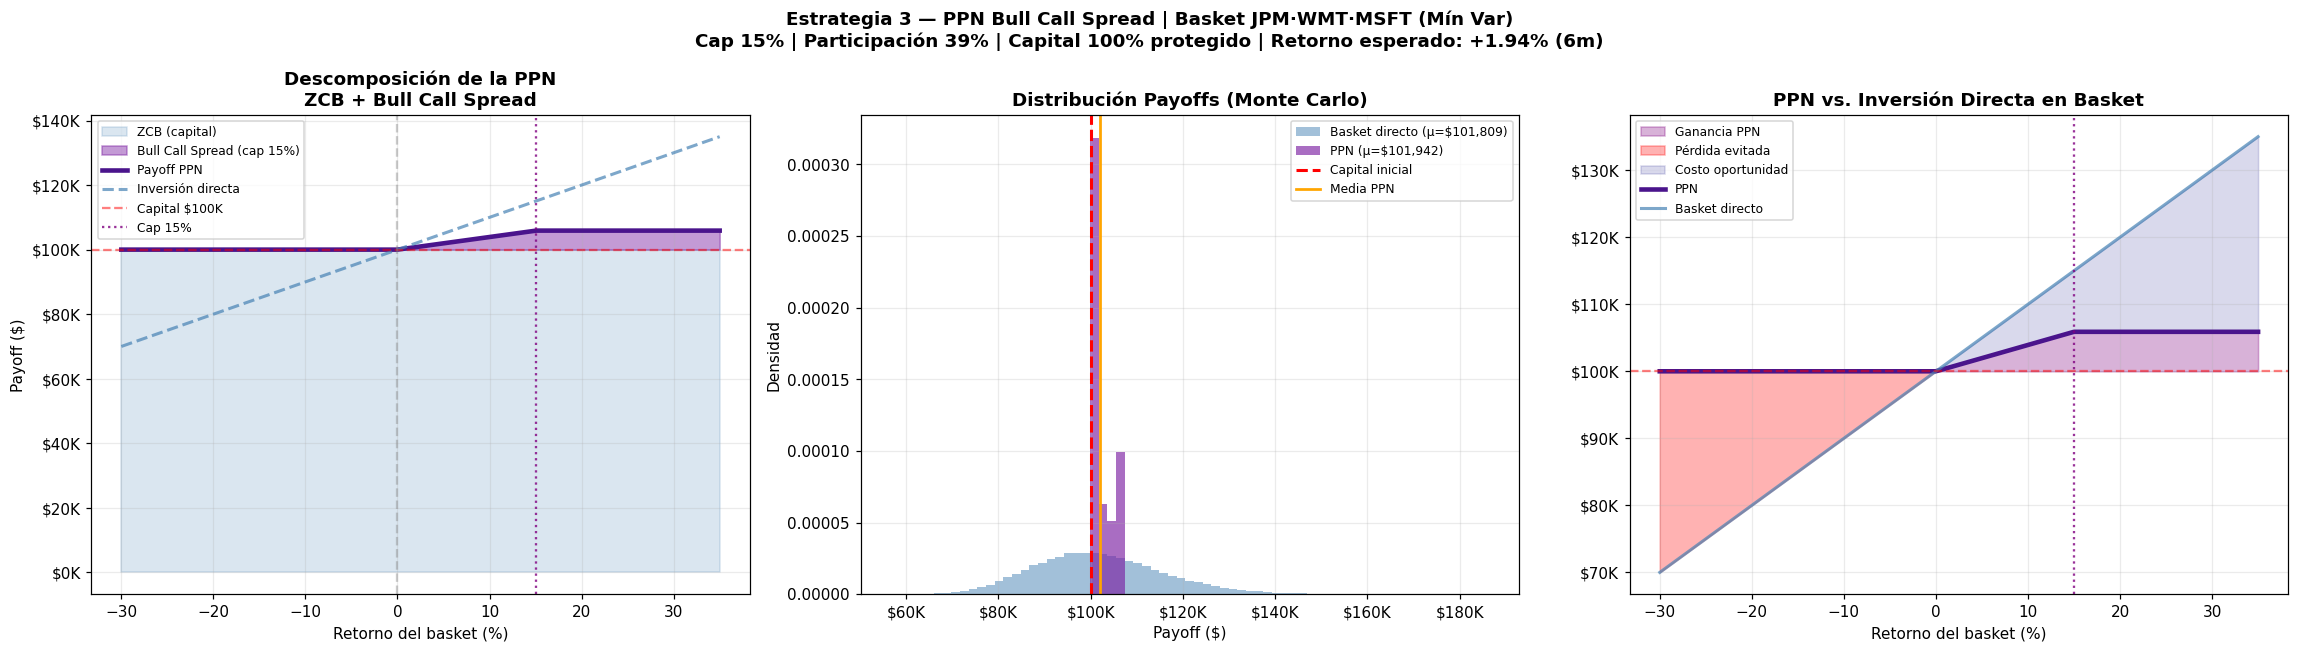

In [96]:
br_s3     = np.linspace(-0.30, 0.35, 500)
zcb_s3    = np.full(len(br_s3), NOTIONAL)
spread_s3 = np.minimum(np.maximum(br_s3, 0), S3_CAP) * NOTIONAL * S3_PARTICIPATION
total_s3  = zcb_s3 + spread_s3
direct_s3 = NOTIONAL * (1 + br_s3)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Panel 1: Descomposición ZCB + Bull Call Spread
ax = axes[0]
ax.fill_between(br_s3*100, 0, zcb_s3, alpha=0.20, color='steelblue', label='ZCB (capital)')
ax.fill_between(br_s3*100, zcb_s3, total_s3,
                alpha=0.45, color='#7B1FA2', label=f'Bull Call Spread (cap {S3_CAP*100:.0f}%)')
ax.plot(br_s3*100, total_s3,  lw=3,   color='#4A148C', label='Payoff PPN')
ax.plot(br_s3*100, direct_s3, lw=2,   color='steelblue', ls='--', alpha=0.7, label='Inversión directa')
ax.axhline(NOTIONAL, color='red', ls='--', alpha=0.5, lw=1.5, label=f'Capital ${NOTIONAL/1000:.0f}K')
ax.axvline(0,           color='gray',   ls='--', alpha=0.4)
ax.axvline(S3_CAP*100,  color='purple', ls=':',  alpha=0.8, label=f'Cap {S3_CAP*100:.0f}%')
ax.set_title('Descomposición de la PPN\nZCB + Bull Call Spread', fontweight='bold')
ax.set_xlabel('Retorno del basket (%)')
ax.set_ylabel('Payoff ($)')
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.25)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Panel 2: Distribución Monte Carlo (PPN vs Basket directo)
ax = axes[1]
lo3  = min(direct_mc_s3.min(), payoff3.min())
hi3  = max(direct_mc_s3.max(), payoff3.max())
bins3 = np.linspace(lo3, hi3, 70)
ax.hist(direct_mc_s3, bins=bins3, alpha=0.50, color='steelblue', density=True,
        label=f'Basket directo (μ=${direct_mc_s3.mean():,.0f})')
ax.hist(payoff3,      bins=bins3, alpha=0.65, color='#7B1FA2',   density=True,
        label=f'PPN (μ=${payoff3.mean():,.0f})')
ax.axvline(NOTIONAL,        color='red',    ls='--', lw=2,   label='Capital inicial')
ax.axvline(payoff3.mean(),  color='orange', ls='-',  lw=1.8, label=f'Media PPN')
ax.set_title('Distribución Payoffs (Monte Carlo)', fontweight='bold')
ax.set_xlabel('Payoff ($)')
ax.set_ylabel('Densidad')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Panel 3: PPN vs Inversión directa en basket
ax = axes[2]
ax.fill_between(br_s3*100, NOTIONAL, total_s3,
                where=total_s3 > NOTIONAL, alpha=0.30, color='purple', label='Ganancia PPN')
ax.fill_between(br_s3*100, NOTIONAL, direct_s3,
                where=direct_s3 < NOTIONAL, alpha=0.30, color='red',   label='Pérdida evitada')
ax.fill_between(br_s3*100, total_s3, direct_s3,
                where=direct_s3 > total_s3, alpha=0.15, color='navy',  label='Costo oportunidad')
ax.plot(br_s3*100, total_s3,  lw=3, color='#4A148C',   label='PPN')
ax.plot(br_s3*100, direct_s3, lw=2, color='steelblue', alpha=0.7, label='Basket directo')
ax.axhline(NOTIONAL, color='red', ls='--', alpha=0.5)
ax.axvline(S3_CAP*100, color='purple', ls=':', alpha=0.8)
ax.set_title('PPN vs. Inversión Directa en Basket', fontweight='bold')
ax.set_xlabel('Retorno del basket (%)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.suptitle(
    f'Estrategia 3 — PPN Bull Call Spread | Basket JPM·WMT·MSFT (Mín Var)\n'
    f'Cap {S3_CAP*100:.0f}% | Participación {S3_PARTICIPATION*100:.0f}% | Capital 100% protegido | '
    f'Retorno esperado: {exp_ret3*100:+.2f}% (6m)',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## S3-F. Distribución del Payoff Total y Comparativa de Retornos

### Características de la distribución de la PPN

La distribución del payoff de la PPN tiene una forma particular con **tres regiones**:

1. **Pico en $100,000 (payoff mínimo):** Todos los escenarios donde el basket termina por debajo del precio inicial. El spread no ejerce valor → el inversor recibe exactamente el capital protegido.

2. **Rampa ascendente ($100K a $109K):** Escenarios con retorno del basket entre 0% y 15%. El inversor captura el 60% de ese retorno. La rampa es continua porque el basket puede terminar en cualquier valor dentro de este rango.

3. **Pico en $109,000 (payoff máximo con participación 60%):** Todos los escenarios donde el basket supera el 15% → el cap está activo y todos esos escenarios reciben el mismo payoff máximo ($100,000 × (1 + 0.60 × 0.15) = $109,000).

### Panel 2 — Retornos comparativos

Compara la distribución de retornos de la PPN frente a la inversión directa. La PPN "elimina" la cola izquierda negativa y "comprime" la cola derecha al cap, a cambio de una probabilidad alta de recuperar exactamente el capital en escenarios planos o bajistas.


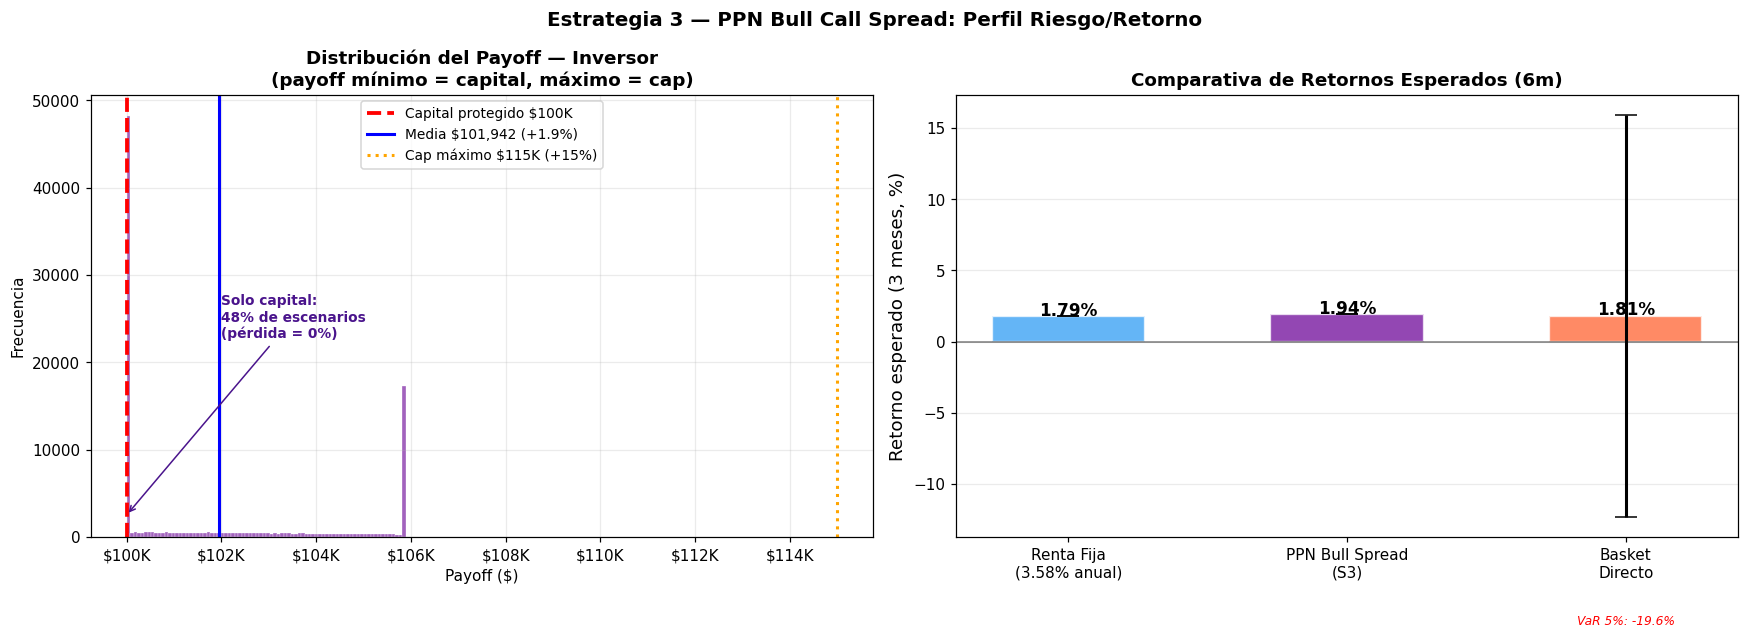

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Histograma del payoff del inversor
ax = axes[0]
ax.hist(payoff3, bins=80, color='#7B1FA2', alpha=0.7, edgecolor='white', linewidth=0.3)
ax.axvline(NOTIONAL,        color='red',    ls='--', lw=2.5,
           label=f'Capital protegido ${NOTIONAL/1000:.0f}K')
ax.axvline(payoff3.mean(),  color='blue',   ls='-',  lw=2,
           label=f'Media ${payoff3.mean():,.0f} ({exp_ret3*100:+.1f}%)')
ax.axvline(NOTIONAL*(1+S3_CAP), color='orange', ls=':', lw=2,
           label=f'Cap máximo ${NOTIONAL*(1+S3_CAP)/1000:.0f}K (+{S3_CAP*100:.0f}%)')
only_cap_pct3 = (payoff3 <= NOTIONAL + 1).mean() * 100
ax.annotate(f'Solo capital:\n{only_cap_pct3:.0f}% de escenarios\n(pérdida = 0%)',
            xy=(NOTIONAL, ax.get_ylim()[1]*0.05 if ax.get_ylim()[1] > 0 else 1000),
            xytext=(NOTIONAL * 1.02, ax.get_ylim()[1]*0.45 if ax.get_ylim()[1] > 0 else 5000),
            fontsize=9, color='#4A148C', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#4A148C'))
ax.set_title('Distribución del Payoff — Inversor\n(payoff mínimo = capital, máximo = cap)', fontweight='bold')
ax.set_xlabel('Payoff ($)')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Panel 2: Comparativa de retornos esperados
ax2 = axes[1]
rf_return_s3    = S3_RISK_FREE * S3_T * 100
note_return_s3  = exp_ret3 * 100
direct_mean_s3  = float(basket_ret_sim.mean()) * 100
direct_std_s3   = float(basket_ret_sim.std()) * 100
direct_worst_s3 = float(np.percentile(basket_ret_sim, 5)) * 100

strat_labels_s3 = [f'Renta Fija\n({S3_RISK_FREE*100:.2f}% anual)', 'PPN Bull Spread\n(S3)', 'Basket\nDirecto']
bar_vals_s3     = [rf_return_s3, note_return_s3, direct_mean_s3]
bcolors_s3      = ['#42A5F5', '#7B1FA2', '#FF7043']

bars3 = ax2.bar(strat_labels_s3, bar_vals_s3, color=bcolors_s3, alpha=0.82,
                edgecolor='white', linewidth=1.5, width=0.55)
ax2.errorbar(strat_labels_s3, bar_vals_s3, yerr=[0, 0, direct_std_s3],
             fmt='none', color='black', capsize=7, linewidth=2)
for bar, val in zip(bars3, bar_vals_s3):
    ax2.text(bar.get_x() + bar.get_width()/2, max(val, 0) + 0.05,
             f'{val:.2f}%', ha='center', fontweight='bold', fontsize=11)
ax2.text(2, direct_worst_s3 - 0.35, f'VaR 5%: {direct_worst_s3:.1f}%',
         ha='center', fontsize=8, color='red', style='italic')
ax2.axhline(0, color='black', lw=1, alpha=0.5)
ax2.set_ylabel('Retorno esperado (3 meses, %)', fontsize=12)
ax2.set_title('Comparativa de Retornos Esperados (6m)', fontweight='bold')
ax2.grid(True, alpha=0.25, axis='y')

plt.suptitle('Estrategia 3 — PPN Bull Call Spread: Perfil Riesgo/Retorno',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## S3-G. Tabla de Escenarios Numéricos

Análisis determinista para los tres activos del basket, calculando primero el valor ponderado y luego el payoff de la nota.

| Escenario | Descripción |
|---|---|
| **Rally generalizado +20%** | El basket supera el cap → payoff máximo ($109K) |
| **Cap exacto +15%** | Basket en el límite del cap → último punto de retorno creciente |
| **Alza moderada +10%** | Basket por debajo del cap → inversor captura el 60% del retorno |
| **JPM/WMT/MSFT asimétricos** | Un sector lidera → muestra el efecto de la ponderación min-var |
| **Flat (0%)** | Sin movimiento → se devuelve exactamente el capital |
| **Corrección -5% a -20%** | Protección activa → payoff = $100,000 en todos los casos bajistas |
| **Rally extremo +30%** | Cap activo → mismo payoff que si el basket subiera exactamente +15% |


In [98]:
# Tabla de escenarios para los tres activos del basket S3
print("\n" + "=" * 105)
print("  ANÁLISIS DE ESCENARIOS — PPN BULL CALL SPREAD (JPM · WMT · MSFT)")
print("=" * 105)

scenarios_s3 = [
    ( 0.20,  0.20,  0.20, "Rally generalizado +20%  ← CAP ACTIVO"),
    ( 0.15,  0.15,  0.15, "Alza +15% — exactamente en el cap"),
    ( 0.10,  0.10,  0.10, "Alza moderada +10%"),
    ( 0.20,  0.05,  0.15, "JPM lidera / WMT rezagado"),
    ( 0.05,  0.20,  0.10, "WMT lidera"),
    ( 0.10,  0.10,  0.20, "MSFT acelera / JPM y WMT moderados"),
    ( 0.05,  0.05,  0.05, "Leve alza +5%"),
    ( 0.00,  0.00,  0.00, "Flat (sin movimiento)"),
    (-0.05, -0.05, -0.05, "Leve corrección -5%  ← capital protegido"),
    (-0.10, -0.15, -0.10, "Corrección moderada"),
    (-0.20, -0.20, -0.20, "Corrección severa -20%"),
    ( 0.30,  0.25,  0.35, "Rally extremo (cap activo al 15%)"),
]

rows_s3 = []
for r_jpm, r_wmt, r_msft, desc in scenarios_s3:
    rets_sc   = np.array([r_jpm, r_wmt, r_msft])
    finals_sc = (spots_s3 * (1 + rets_sc)).reshape(1, -1)
    pf_sc, bask_sc, der_sc = ppn_basket_payoff(
        finals_sc, weights_s3, basket_spot, K1_s3, K2_s3, NOTIONAL, S3_PARTICIPATION
    )
    bask_ret_sc = (float(bask_sc[0]) - basket_spot) / basket_spot
    cap_hit     = bask_ret_sc >= S3_CAP - 1e-4
    ganancia    = float(pf_sc[0]) > NOTIONAL + 0.01
    resultado   = (f'🔒 Cap ({S3_CAP*100:.0f}%)' if cap_hit
                   else ('✅ Ganancia' if ganancia else '⬜ Solo capital'))
    rows_s3.append({
        'Escenario':      desc,
        'JPM':            f'{r_jpm*100:+.0f}%',
        'WMT':            f'{r_wmt*100:+.0f}%',
        'MSFT':           f'{r_msft*100:+.0f}%',
        'Basket ret':     f'{bask_ret_sc*100:+.2f}%',
        'Spread ($)':     f'${der_sc[0]:>8,.0f}',
        'Payoff total':   f'${pf_sc[0]:>10,.0f}',
        'Rend. 3m':       f'{(float(pf_sc[0])/NOTIONAL - 1)*100:+.2f}%',
        'Resultado':      resultado,
    })

df_s3 = pd.DataFrame(rows_s3)
print(df_s3.to_string(index=False))
df_s3


  ANÁLISIS DE ESCENARIOS — PPN BULL CALL SPREAD (JPM · WMT · MSFT)
                               Escenario  JPM  WMT MSFT Basket ret Spread ($) Payoff total Rend. 3m      Resultado
   Rally generalizado +20%  ← CAP ACTIVO +20% +20% +20%    +20.00%  $   5,890  $   105,890   +5.89%    🔒 Cap (15%)
       Alza +15% — exactamente en el cap +15% +15% +15%    +15.00%  $   5,890  $   105,890   +5.89%    🔒 Cap (15%)
                      Alza moderada +10% +10% +10% +10%    +10.00%  $   3,926  $   103,926   +3.93%     ✅ Ganancia
               JPM lidera / WMT rezagado +20%  +5% +15%    +14.90%  $   5,849  $   105,849   +5.85%     ✅ Ganancia
                              WMT lidera  +5% +20% +10%    +10.10%  $   3,967  $   103,967   +3.97%     ✅ Ganancia
      MSFT acelera / JPM y WMT moderados +10% +10% +20%    +14.79%  $   5,806  $   105,806   +5.81%     ✅ Ganancia
                           Leve alza +5%  +5%  +5%  +5%     +5.00%  $   1,963  $   101,963   +1.96%     ✅ Ganancia
            

,Escenario,JPM,WMT,MSFT,Basket ret,Spread ($),Payoff total,Rend. 3m,Resultado
0,Rally generalizado +20% ← CAP ACTIVO,+20%,+20%,+20%,+20.00%,"$ 5,890","$ 105,890",+5.89%,🔒 Cap (15%)
1,Alza +15% — exactamente en el cap,+15%,+15%,+15%,+15.00%,"$ 5,890","$ 105,890",+5.89%,🔒 Cap (15%)
2,Alza moderada +10%,+10%,+10%,+10%,+10.00%,"$ 3,926","$ 103,926",+3.93%,✅ Ganancia
3,JPM lidera / WMT rezagado,+20%,+5%,+15%,+14.90%,"$ 5,849","$ 105,849",+5.85%,✅ Ganancia
4,WMT lidera,+5%,+20%,+10%,+10.10%,"$ 3,967","$ 103,967",+3.97%,✅ Ganancia
5,MSFT acelera / JPM y WMT moderados,+10%,+10%,+20%,+14.79%,"$ 5,806","$ 105,806",+5.81%,✅ Ganancia
6,Leve alza +5%,+5%,+5%,+5%,+5.00%,"$ 1,963","$ 101,963",+1.96%,✅ Ganancia
7,Flat (sin movimiento),+0%,+0%,+0%,+0.00%,$ 0,"$ 100,000",+0.00%,⬜ Solo capital
8,Leve corrección -5% ← capital protegido,-5%,-5%,-5%,-5.00%,$ 0,"$ 100,000",+0.00%,⬜ Solo capital
9,Corrección moderada,-10%,-15%,-10%,-10.90%,$ 0,"$ 100,000",+0.00%,⬜ Solo capital


---
# 📋 Resumen Comparativo — Las Tres Estrategias

Esta tabla consolida los indicadores más relevantes de cada estrategia para facilitar la comparación directa.

### Guía de lectura

| Métrica | Descripción |
|---|---|
| **Fair Value** | Valor presente del payoff esperado bajo riesgo neutro (Monte Carlo). Si es cercano al Notional ($100K), la nota es eficiente. |
| **Margen banco** | NOTIONAL − Fair Value = margen implícito del emisor. Incluye costo de garantía, distribución y beneficio. |
| **Retorno esperado** | Retorno promedio sobre el capital en el plazo de la nota. |
| **Prob. de ganancia** | % de escenarios donde el inversor recibe más de $100,000. |
| **Payoff mínimo** | Verifica que la protección de capital es real (= $100,000 siempre). |
| **Payoff máximo** | Cap efectivo de la estrategia. |

### ¿Cuál estrategia elegir?

| Perfil de inversor | Estrategia recomendada |
|---|---|
| Quiere exposición al sector tech con alta prob. de alguna ganancia | **S1 — Nota Best-Of** |
| Tiene una visión clara de divergencia sectorial MSFT↑/XOM↓ | **S2 — Nota Direccional** |
| Prefiere exposición diversificada con menor volatilidad | **S3 — PPN Basket** |
| Busca el mayor retorno esperado en escenario bajista | **Cualquiera** (las tres protegen el 100%) |


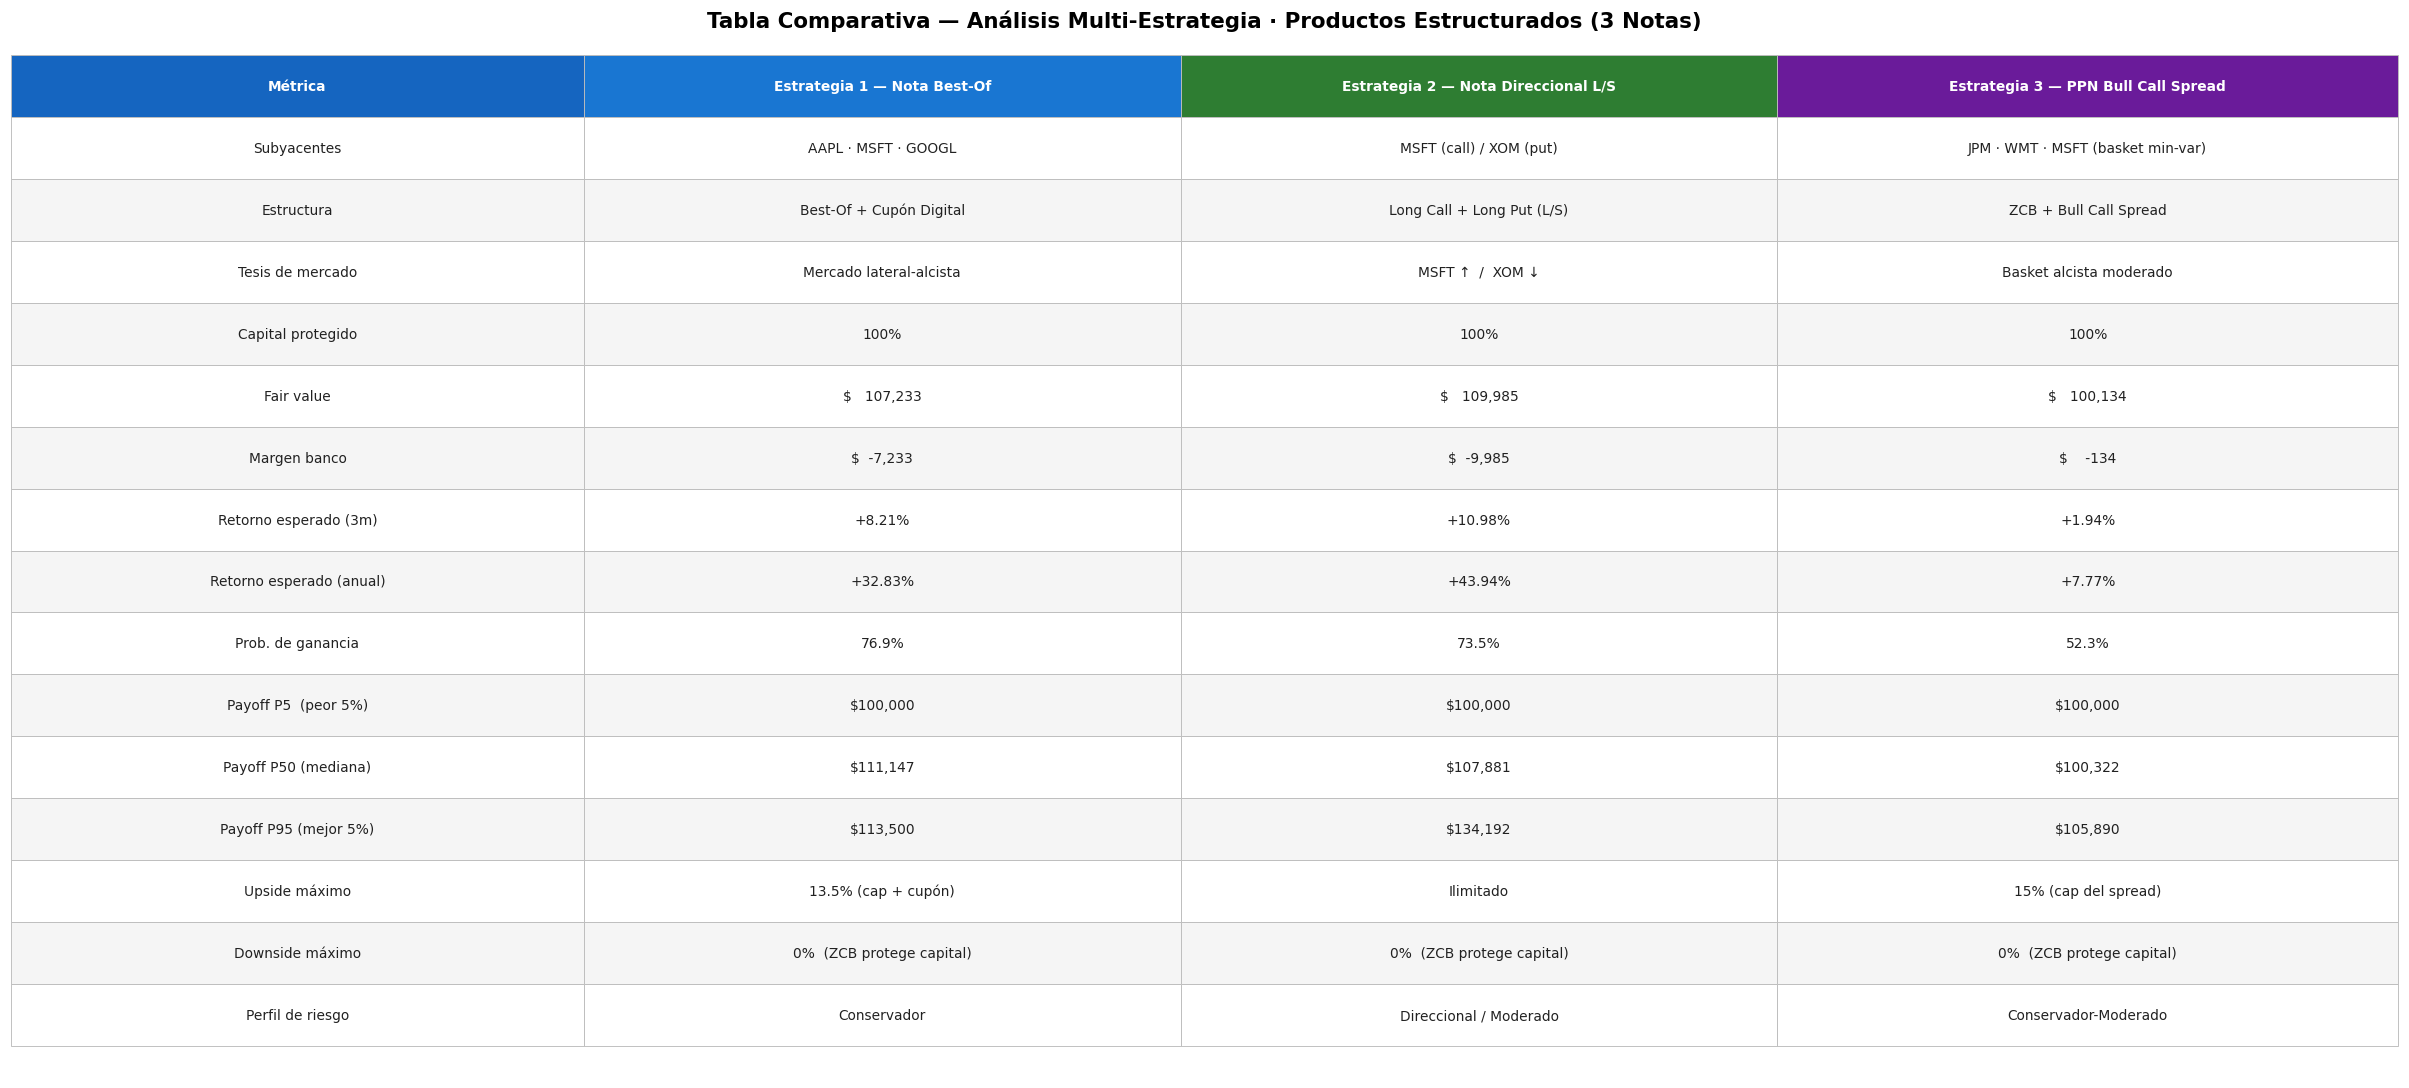

In [99]:
# Tabla visual comparativa con las métricas clave de las tres estrategias
# ── Tabla visual comparativa — las 3 estrategias ────────────────────────────
fig, ax = plt.subplots(figsize=(22, 10))
ax.axis('off')

metrics = [
    ['Métrica',
     'Estrategia 1 — Nota Best-Of',
     'Estrategia 2 — Nota Direccional L/S',
     'Estrategia 3 — PPN Bull Call Spread'],
    ['Subyacentes',
     'AAPL · MSFT · GOOGL',
     'MSFT (call) / XOM (put)',
     'JPM · WMT · MSFT (basket min-var)'],
    ['Estructura',
     'Best-Of + Cupón Digital',
     'Long Call + Long Put (L/S)',
     'ZCB + Bull Call Spread'],
    ['Tesis de mercado',
     'Mercado lateral-alcista',
     'MSFT ↑  /  XOM ↓',
     'Basket alcista moderado'],
    ['Capital protegido',
     '100%', '100%', '100%'],
    ['Fair value',
     f'${fair_value1:>10,.0f}',
     f'${fair_value2:>10,.0f}',
     f'${fair_value3:>10,.0f}'],
    ['Margen banco',
     f'${NOTIONAL - fair_value1:>8,.0f}',
     f'${NOTIONAL - fair_value2:>8,.0f}',
     f'${NOTIONAL - fair_value3:>8,.0f}'],
    ['Retorno esperado (3m)',
     f'{exp_ret1*100:+.2f}%',
     f'{exp_ret2*100:+.2f}%',
     f'{exp_ret3*100:+.2f}%'],
    ['Retorno esperado (anual)',
     f'{exp_ret1/T*100:+.2f}%',
     f'{exp_ret2/T*100:+.2f}%',
     f'{exp_ret3/T*100:+.2f}%'],
    ['Prob. de ganancia',
     f'{(payoff1>NOTIONAL).mean()*100:.1f}%',
     f'{(payoff2>NOTIONAL).mean()*100:.1f}%',
     f'{(payoff3>NOTIONAL).mean()*100:.1f}%'],
    ['Payoff P5  (peor 5%)',
     f'${np.percentile(payoff1,  5):,.0f}',
     f'${np.percentile(payoff2,  5):,.0f}',
     f'${np.percentile(payoff3,  5):,.0f}'],
    ['Payoff P50 (mediana)',
     f'${np.percentile(payoff1, 50):,.0f}',
     f'${np.percentile(payoff2, 50):,.0f}',
     f'${np.percentile(payoff3, 50):,.0f}'],
    ['Payoff P95 (mejor 5%)',
     f'${np.percentile(payoff1, 95):,.0f}',
     f'${np.percentile(payoff2, 95):,.0f}',
     f'${np.percentile(payoff3, 95):,.0f}'],
    ['Upside máximo',
     f'{(S1_CAP+S1_COUPON)*100:.1f}% (cap + cupón)',
     'Ilimitado',
     f'{S3_CAP*100:.0f}% (cap del spread)'],
    ['Downside máximo',
     '0%  (ZCB protege capital)',
     '0%  (ZCB protege capital)',
     '0%  (ZCB protege capital)'],
    ['Perfil de riesgo',
     'Conservador',
     'Direccional / Moderado',
     'Conservador-Moderado'],
]

col_widths = [0.24, 0.25, 0.25, 0.26]
col_starts = [0.0,  0.24, 0.49, 0.74]
row_height = 1 / (len(metrics) + 0.5)

header_clr = '#1565C0'
s1_clr     = '#1976D2'
s2_clr     = '#2E7D32'
s3_clr     = '#6A1B9A'
even_clr   = '#F5F5F5'
odd_clr    = '#FFFFFF'

for r, row in enumerate(metrics):
    for c, (txt, cw, cx) in enumerate(zip(row, col_widths, col_starts)):
        if r == 0:
            bg = header_clr if c == 0 else {1: s1_clr, 2: s2_clr, 3: s3_clr}[c]
            fc, fw = 'white', 'bold'
        else:
            bg = even_clr if r % 2 == 0 else odd_clr
            fc, fw = '#212121', 'normal'

        y_bot = 1 - (r + 1) * row_height
        rect = plt.Rectangle((cx, y_bot), cw, row_height,
                              facecolor=bg, edgecolor='#BDBDBD', linewidth=0.6,
                              transform=ax.transAxes, clip_on=False)
        ax.add_patch(rect)
        ax.text(cx + cw / 2, y_bot + row_height / 2, txt,
                ha='center', va='center', fontsize=9,
                color=fc, fontweight=fw, transform=ax.transAxes)

ax.set_title(
    'Tabla Comparativa — Análisis Multi-Estrategia · Productos Estructurados (3 Notas)',
    fontsize=14, fontweight='bold', pad=18
)
plt.tight_layout()
plt.show()